In [1]:
import numpy as np
import matplotlib.pyplot as plt 
from pathlib import Path

In [ ]:
log_dir = Path("/home/max/PhD/programs/su2/pure_gauge/raw_data/logs") 

logs = list(log_dir.glob("*.log"))

for log in logs:
    print(log.name)

L8x8x8x8_beta2_md15_trajL1.0_traj1000_ckpt5.log
L8x8x8x8_beta2_md10_trajL1.0_traj1000_ckpt5.log
L8x8x8x8_beta2_md20_trajL1.0_traj1000_ckpt5.log
L8x8x8x8_beta2_md5_trajL1.0_traj1000_ckpt5.log


In [4]:
import re
from pathlib import Path

def parse_log_name(path):

    name = path.name

    result = {}

    m = re.search(r"L(\d+x\d+x\d+x\d+)", name)
    if m:
        result["lattice"] = m.group(1)

    m = re.search(r"_beta([\d.]+)", name)
    if m:
        result["beta"] = float(m.group(1))

    m = re.search(r"_md(\d+)", name)
    if m:
        result["mdsteps"] = int(m.group(1))

    m = re.search(r"_trajL([\d.]+)", name)
    if m:
        result["trajL"] = float(m.group(1))

    m = re.search(r"_traj(\d+)", name)
    if m:
        result["trajectories"] = int(m.group(1))

    m = re.search(r"_ckpt(\d+)", name)
    if m:
        result["checkpoint"] = int(m.group(1))

    return result

In [5]:
for log in logs:
    print(parse_log_name(log))

{'lattice': '8x8x8x8', 'beta': 2.0, 'mdsteps': 15, 'trajL': 1.0, 'trajectories': 1000, 'checkpoint': 5}
{'lattice': '8x8x8x8', 'beta': 2.0, 'mdsteps': 10, 'trajL': 1.0, 'trajectories': 1000, 'checkpoint': 5}
{'lattice': '8x8x8x8', 'beta': 2.0, 'mdsteps': 20, 'trajL': 1.0, 'trajectories': 1000, 'checkpoint': 5}
{'lattice': '8x8x8x8', 'beta': 2.0, 'mdsteps': 5, 'trajL': 1.0, 'trajectories': 1000, 'checkpoint': 5}


In [6]:
import pandas as pd

data = []

for log in logs:
    row = parse_log_name(log)
    row["file"] = log
    data.append(row)

df = pd.DataFrame(data)

df

,lattice,beta,mdsteps,trajL,trajectories,checkpoint,file
0,8x8x8x8,2.0,15,1.0,1000,5,/home/max/PhD/programs/su2/pure_gauge/raw_data...
1,8x8x8x8,2.0,10,1.0,1000,5,/home/max/PhD/programs/su2/pure_gauge/raw_data...
2,8x8x8x8,2.0,20,1.0,1000,5,/home/max/PhD/programs/su2/pure_gauge/raw_data...
3,8x8x8x8,2.0,5,1.0,1000,5,/home/max/PhD/programs/su2/pure_gauge/raw_data...


In [7]:
def parse_plaquette(logfile):

    data = []

    with open(logfile) as f:
        for line in f:

            m = re.search(
                r"Plaquette:\s+\[\s*(\d+)\s*\]\s+([\d\.Ee+-]+)",
                line
            )

            if m:
                data.append(
                    {
                        "trajectory": int(m.group(1)),
                        "plaquette": float(m.group(2))
                    }
                )

    df = pd.DataFrame(data)

    # doppelte MPI-Ausgaben entfernen
    df = df.drop_duplicates(
        subset=["trajectory", "plaquette"]
    )

    return df.to_dict("records")

In [8]:
measurements = []

for log in logs:

    # Parameter aus Dateinamen
    params = parse_log_name(log)

    # Plaquette Werte aus Log
    plaqs = parse_plaquette(log)

    for p in plaqs:
        p.update(params)
        p["file"] = log.name
        measurements.append(p)


df = pd.DataFrame(measurements)

df.head()

,trajectory,plaquette,lattice,beta,mdsteps,trajL,trajectories,checkpoint,file
0,1,0.395562,8x8x8x8,8.0,10,1.0,1000,5,L8x8x8x8_beta8_md10_trajL1.0_traj1000_ckpt5.log
1,2,0.607642,8x8x8x8,8.0,10,1.0,1000,5,L8x8x8x8_beta8_md10_trajL1.0_traj1000_ckpt5.log
2,3,0.741551,8x8x8x8,8.0,10,1.0,1000,5,L8x8x8x8_beta8_md10_trajL1.0_traj1000_ckpt5.log
3,4,0.811395,8x8x8x8,8.0,10,1.0,1000,5,L8x8x8x8_beta8_md10_trajL1.0_traj1000_ckpt5.log
4,5,0.846390,8x8x8x8,8.0,10,1.0,1000,5,L8x8x8x8_beta8_md10_trajL1.0_traj1000_ckpt5.log


In [ ]:
df_hdf5 = df.to_hdf("/home/max/PhD/programs/su2/pure_gauge/data/plaquette_measurements.h5", key="plaquette", mode="w") #zu raw_data hinzufügen

In [9]:

df_beta_scan = df[(df.mdsteps == 10) &(df.trajL == 1.0)]
df_beta_scan = df_beta_scan[df_beta_scan.beta != 5.6] # 5.6 run ignorieren

df_mdsteps_scan = df[(df.beta == 2) & (df.trajL == 1.0) & (df.mdsteps != 40)]
df_trajL_scan = df[(df.beta == 2) & (df.mdsteps == 10)]

df_traj100 = df_beta_scan[df_beta_scan.trajectories==100]
df_traj1000 = df_beta_scan[df_beta_scan.trajectories==1000]

df_mdsteps_traj100 = df_mdsteps_scan[df_mdsteps_scan.trajectories == 100]
df_mdsteps_traj1000 = df_mdsteps_scan[df_mdsteps_scan.trajectories == 1000]

df_trajL_traj100 = df_trajL_scan[df_trajL_scan.trajectories == 100]
df_trajL_traj1000 = df_trajL_scan[df_trajL_scan.trajectories == 1000]

In [66]:
#Plotfunktion plaquette vs trajectories für alle beta
def plot_plaquette_history(df_plot, title=None):
    
    plt.figure(figsize=(8,5), layout="constrained")

    for beta in sorted(df_plot.beta.unique()):
        subset = (
            df_plot[df_plot.beta == beta]
            .sort_values("trajectory")
        )

        plt.plot(
            subset.trajectory,
            subset.plaquette,
            ".",
            label=fr"$\beta={beta}$"
        )

    plt.xlabel("trajectory")
    plt.ylabel("plaquette")
    plt.legend()
    plt.grid()

    if title:
        plt.title(title)

    plt.show()

In [68]:
df_traj100.to_csv("/home/max/PhD/programs/su2/pure_gauge/assets/data/plaquette_measurements_traj100.csv", index=False)
df_traj1000.to_csv("/home/max/PhD/programs/su2/pure_gauge/assets/data/plaquette_measurements_traj1000.csv", index=False)


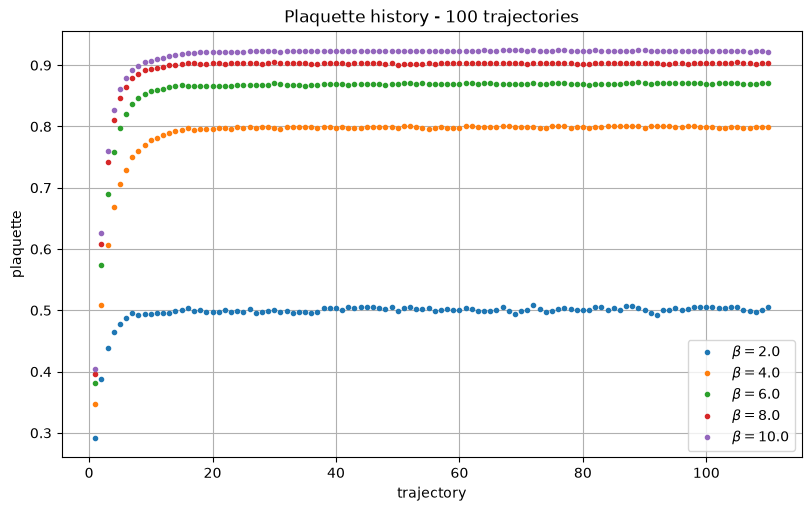

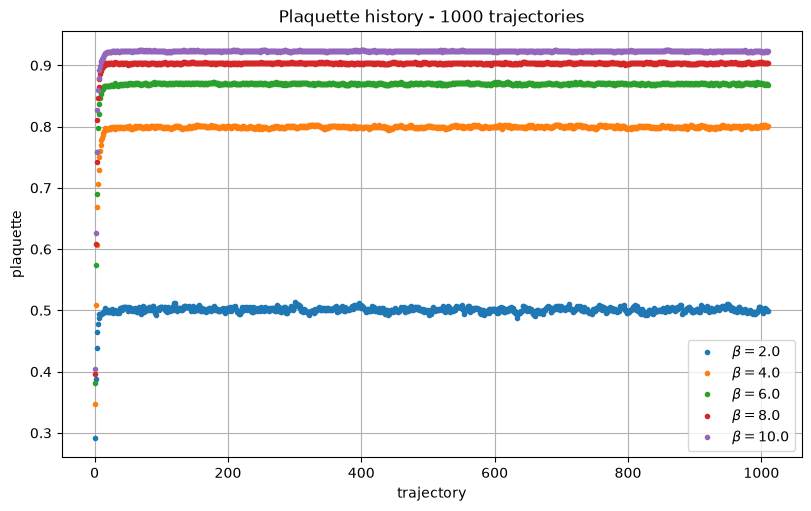

In [67]:
plot_plaquette_history(df_traj100, "Plaquette history - 100 trajectories") #namen der spalten anpassen
plot_plaquette_history(df_traj1000, "Plaquette history - 1000 trajectories")
    

In [12]:
df_phys_traj100 = df_traj100[df_traj100.trajectory > 20] #thermalisieren abschneiden beta scan
df_phys_traj1000 = df_traj1000[df_traj1000.trajectory > 100] #beta scan

df_phys_mdsteps_traj100 = df_mdsteps_traj100[df_mdsteps_traj100.trajectory > 20]
df_phys_mdsteps_traj1000 = df_mdsteps_traj1000[df_mdsteps_traj1000.trajectory > 100]

df_phys_trajL_traj100 = df_trajL_traj100[df_trajL_traj100.trajectory > 20]
df_phys_trajL_traj1000 = df_trajL_traj1000[df_trajL_traj1000.trajectory > 100]

In [13]:
def plot_hist_plaquette(df, beta, bins=30):

    values = df["plaquette"]

    mean = values.mean()
    std = values.std()

    plt.figure(figsize=(8,5))

    plt.hist(
        values,
        bins=bins,
        density=True,
        alpha=0.7,
        rwidth=0.5
    )

    plt.axvline(
        mean,
        linestyle="--",
        label=fr"$\langle P\rangle={mean:.5f}$"
    )

    plt.xlabel(r"$P$")
    plt.ylabel("Probability density")
    plt.title(fr"Plaquette distribution $\beta={beta}$, x axis range 5$\sigma$")
    plt.legend()
    plt.grid()

    plt.xlim(
        mean - 5*std,
        mean + 5*std
    )

    plt.show()

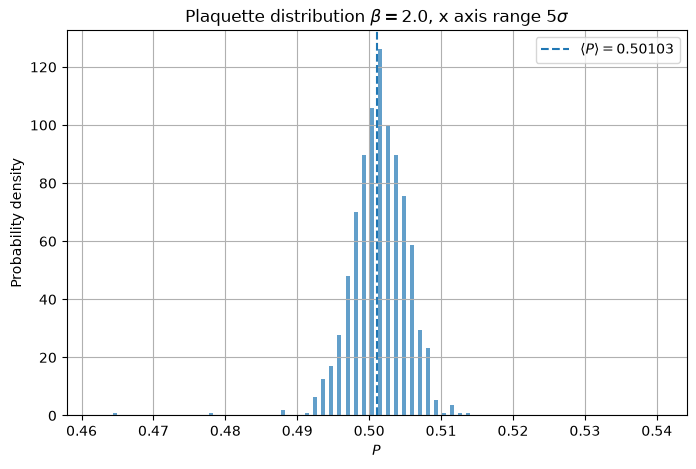

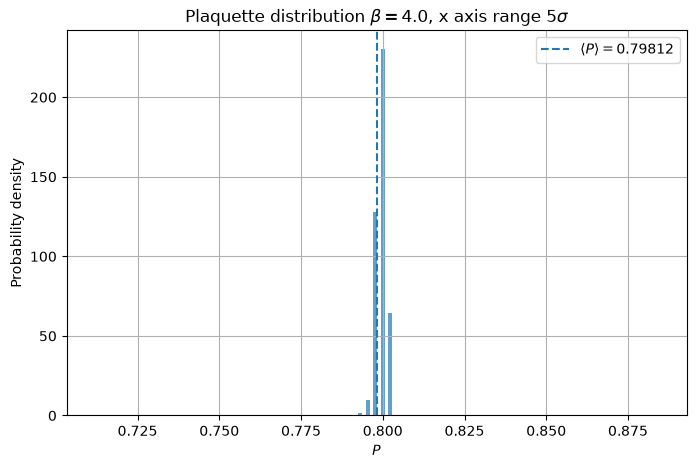

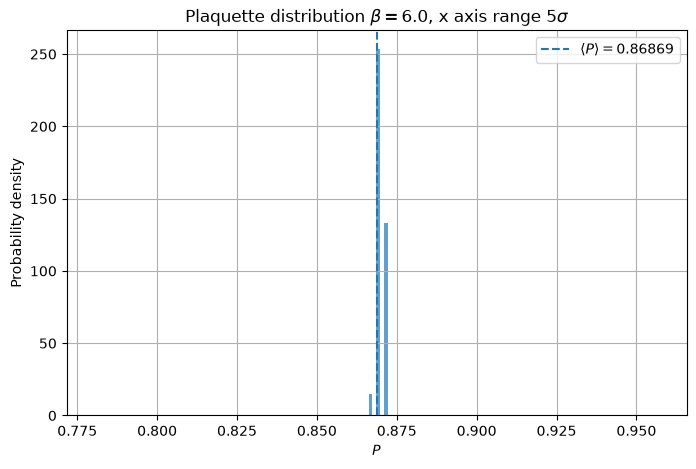

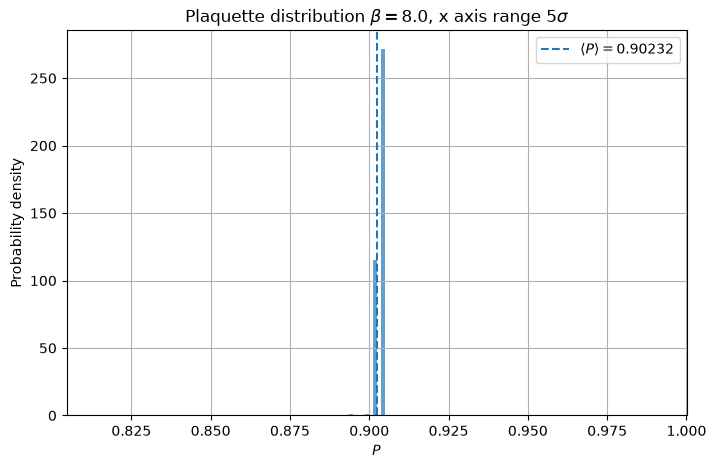

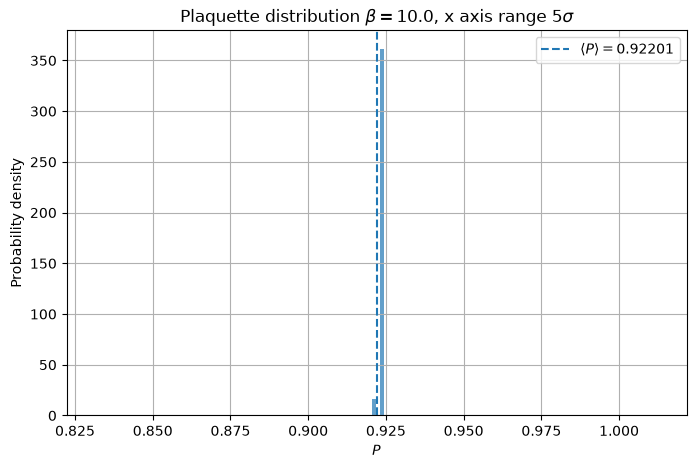

In [14]:
for beta in sorted(df_traj1000.beta.unique()):
    
    subset = df_traj1000[
        df_traj1000.beta == beta
    ]
    
    plot_hist_plaquette(
        subset,
        beta,
        bins=200
    )

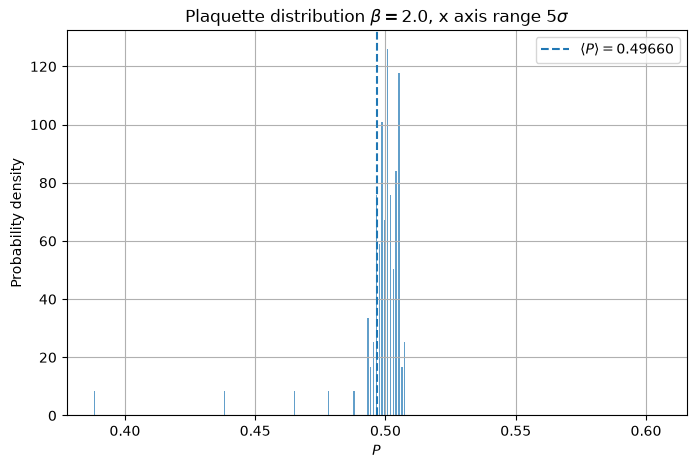

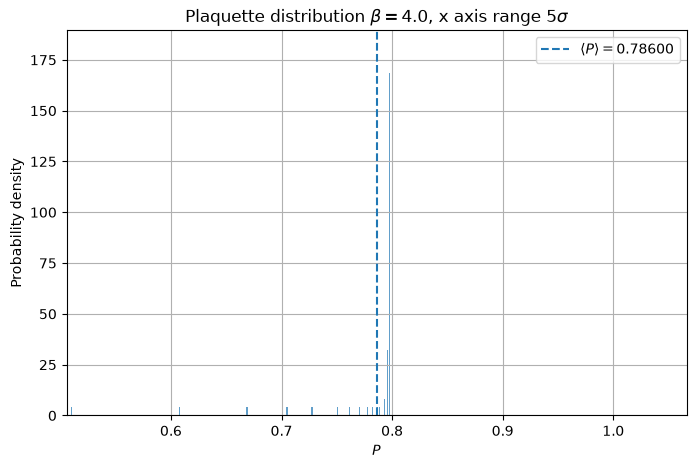

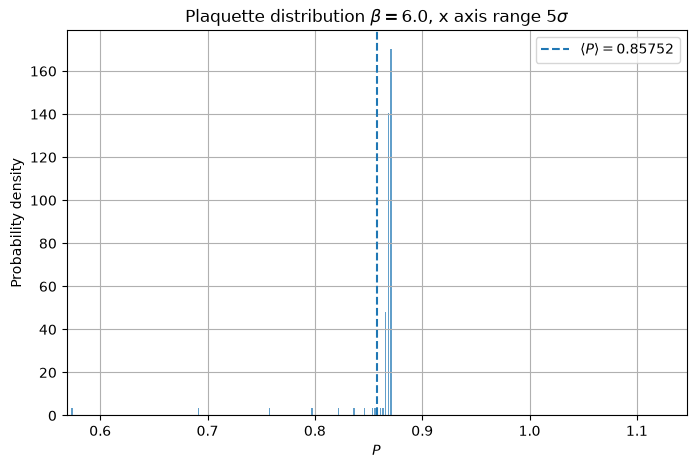

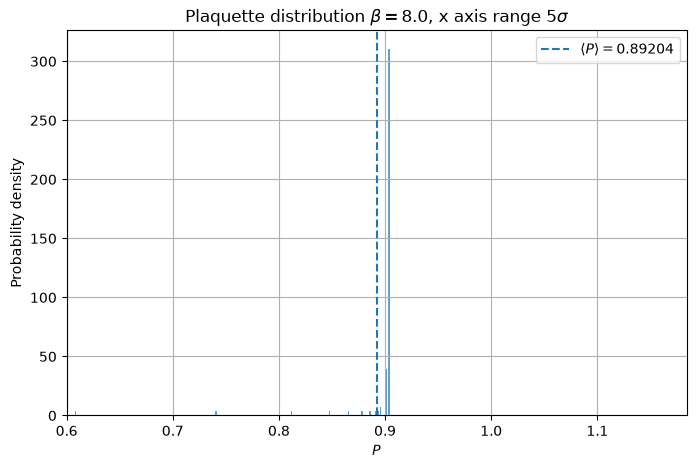

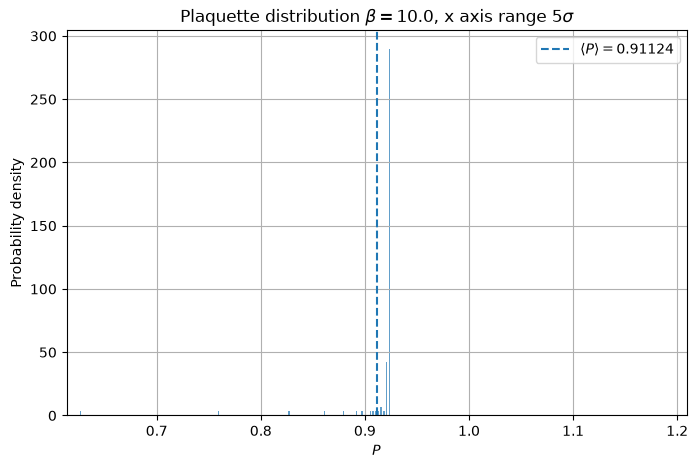

In [15]:
for beta in sorted(df_traj100.beta.unique()):
    
    subset = df_traj100[
        df_traj100.beta == beta
    ]
    
    plot_hist_plaquette(
        subset,
        beta,
        bins=200
    )

In [16]:
def plaq_stats(df):

    stats = (
        df
        .groupby("beta")
        .plaquette
        .agg(
            N="count",
            mean="mean",
            std="std"
        ).sort_index()
    )

    stats["sem"] = stats["std"] / np.sqrt(stats["N"])

    return stats

In [17]:
plaq_stats(df_phys_traj100) #Tabellenausgabe automatisieren

,N,mean,std,sem
beta,,,,
2.0,90,0.501305,0.003287,0.000346
4.0,90,0.799032,0.001182,0.000125
6.0,90,0.869522,0.001250,0.000132
8.0,90,0.903327,0.000695,0.000073
10.0,90,0.923347,0.000681,0.000072


In [12]:
def measurement_stats(df, value, groupby):

    stats = (
        df
        .groupby(groupby)[value]
        .agg(
            N="count",
            mean="mean",
            std="std"
        )
        .sort_index()
    )

    stats["sem"] = stats["std"] / np.sqrt(stats["N"])

    return stats.reset_index()

In [19]:
df_plaq_traj100= measurement_stats(df_phys_traj100, "plaquette", "beta")
df_plaq_traj1000= measurement_stats(df_phys_traj1000, "plaquette", "beta")

df_plaq_mdsteps_traj100= measurement_stats(df_phys_mdsteps_traj100, "plaquette", "mdsteps")
df_plaq_mdsteps_traj1000= measurement_stats(df_phys_mdsteps_traj1000, "plaquette", "mdsteps")

df_plaq_trajL_traj100= measurement_stats(df_phys_trajL_traj100, "plaquette", "trajL")
df_plaq_trajL_traj1000= measurement_stats(df_phys_trajL_traj1000, "plaquette", "trajL")

In [20]:
latex_table_plaq_traj100 = df_plaq_traj100.to_latex(index=False) 
latex_table_plaq_traj1000 = df_plaq_traj1000.to_latex(index=False)

latex_table_plaq_mdsteps_traj100 = df_plaq_mdsteps_traj100.to_latex(index=False) 
latex_table_plaq_mdsteps_traj1000 = df_plaq_mdsteps_traj1000.to_latex(index=False)

latex_table_plaq_trajL_traj100 = df_plaq_trajL_traj100.to_latex(index=False) 
latex_table_plaq_trajL_traj1000 = df_plaq_trajL_traj1000.to_latex(index=False)


print(latex_table_plaq_traj100)
print(latex_table_plaq_traj1000)

print(latex_table_plaq_mdsteps_traj100)
print(latex_table_plaq_mdsteps_traj1000)

print(latex_table_plaq_trajL_traj100)
print(latex_table_plaq_trajL_traj1000)

\begin{tabular}{rrrrr}
\toprule
beta & N & mean & std & sem \\
\midrule
2.000000 & 90 & 0.501305 & 0.003287 & 0.000346 \\
4.000000 & 90 & 0.799032 & 0.001182 & 0.000125 \\
6.000000 & 90 & 0.869522 & 0.001250 & 0.000132 \\
8.000000 & 90 & 0.903327 & 0.000695 & 0.000073 \\
10.000000 & 90 & 0.923347 & 0.000681 & 0.000072 \\
\bottomrule
\end{tabular}

\begin{tabular}{rrrrr}
\toprule
beta & N & mean & std & sem \\
\midrule
2.000000 & 910 & 0.501585 & 0.003472 & 0.000115 \\
4.000000 & 910 & 0.799586 & 0.001505 & 0.000050 \\
6.000000 & 910 & 0.870059 & 0.000975 & 0.000032 \\
8.000000 & 910 & 0.903574 & 0.000711 & 0.000024 \\
10.000000 & 910 & 0.923319 & 0.000558 & 0.000018 \\
\bottomrule
\end{tabular}

\begin{tabular}{rrrrr}
\toprule
mdsteps & N & mean & std & sem \\
\midrule
5 & 90 & 0.500406 & 0.003306 & 0.000349 \\
8 & 90 & 0.501233 & 0.003358 & 0.000354 \\
10 & 90 & 0.501305 & 0.003287 & 0.000346 \\
20 & 90 & 0.502592 & 0.003989 & 0.000420 \\
\bottomrule
\end{tabular}

\begin{tabular}{rrr

In [21]:
def plot_plaquette_avr_beta(df, trajectories=None):
    plt.figure(figsize=(8,5))

    plt.errorbar(
        df["beta"],
        df["mean"],
        yerr=df["sem"],
        fmt="o-",
        capsize=3
    )

    plt.xlabel(r"$\beta$")
    plt.ylabel(r"$\langle P\rangle$")

    if trajectories is not None:
        plt.title(
            rf"$\langle P\rangle$ vs $\beta$: {trajectories} trajectories"
        )
    else:
        plt.title(r"$\langle P\rangle$ vs $\beta$")

    plt.grid()
    plt.show()

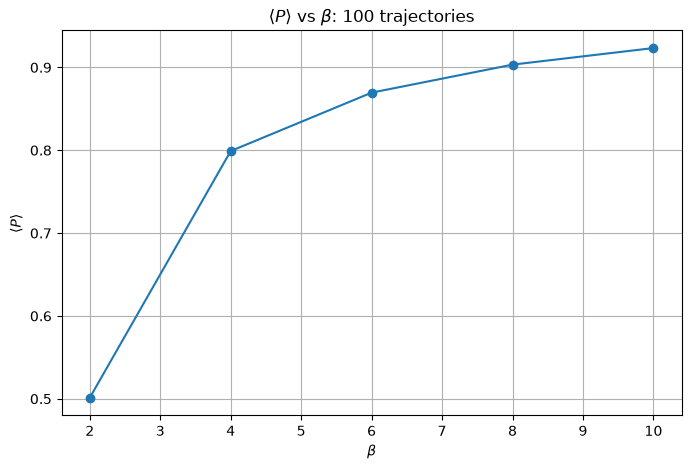

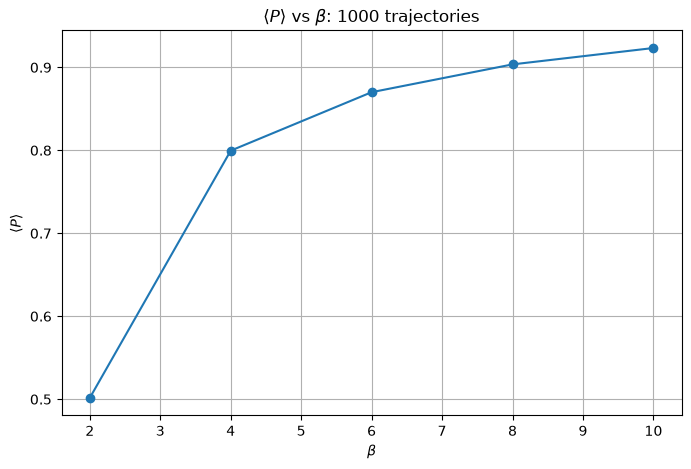

In [22]:
plot_plaquette_avr_beta(df_plaq_traj100, trajectories=100)
plot_plaquette_avr_beta(df_plaq_traj1000, trajectories=1000)

In [23]:
import re

def parse_acceptance(logfile):

    data = []

    with open(logfile) as f:
        trajectory = 0

        for line in f:

            if "Metropolis_test -- ACCEPTED" in line:
                trajectory += 1
                data.append({
                    "trajectory": trajectory,
                    "accepted": 1
                })

            elif "Metropolis_test -- REJECTED" in line:
                trajectory += 1
                data.append({
                    "trajectory": trajectory,
                    "accepted": 0
                })

    return data

In [24]:
measurements = []

for log in logs:

    params = parse_log_name(log)

    acc = parse_acceptance(log)

    for a in acc:
        a.update(params)
        measurements.append(a)

df_acc = pd.DataFrame(measurements)

In [25]:
df_acc_beta_scan = df_acc[
    (df_acc.mdsteps == 10) &
    (df_acc.trajL == 1.0) &
    (df_acc.beta != 5.6)
]

In [26]:
df_acc_100 = df_acc_beta_scan[
    (df_acc_beta_scan.trajectories == 100) &
    (df_acc_beta_scan.trajectory > 10) # kein Metropolistest während des Thermalisierens. entferne 10 weniger Werte als beim Plaquette
]

df_acc_1000 = df_acc_beta_scan[
    (df_acc_beta_scan.trajectories == 1000) &
    (df_acc_beta_scan.trajectory > 90)
]

In [27]:
def acc_stats(df):
    stats =(
    df    
    .groupby("beta")
    .agg(
        N=("accepted", "count"),
        accepted=("accepted", "sum"),
        acceptance=("accepted", "mean")
        )       
    )
    return stats.reset_index()

In [28]:
df_acc_100.groupby(["beta", "mdsteps", "trajL"]).size()

beta  mdsteps  trajL
2.0   10       1.0      90
4.0   10       1.0      90
6.0   10       1.0      90
8.0   10       1.0      90
10.0  10       1.0      90
dtype: int64

In [29]:
acc_100 = acc_stats(df_acc_100)
acc_1000 = acc_stats(df_acc_1000) 

In [30]:
print(acc_100.to_latex(index=False))
print(acc_1000.to_latex(index=False))

\begin{tabular}{rrrr}
\toprule
beta & N & accepted & acceptance \\
\midrule
2.000000 & 90 & 84 & 0.933333 \\
4.000000 & 90 & 83 & 0.922222 \\
6.000000 & 90 & 75 & 0.833333 \\
8.000000 & 90 & 78 & 0.866667 \\
10.000000 & 90 & 73 & 0.811111 \\
\bottomrule
\end{tabular}

\begin{tabular}{rrrr}
\toprule
beta & N & accepted & acceptance \\
\midrule
2.000000 & 910 & 845 & 0.928571 \\
4.000000 & 910 & 807 & 0.886813 \\
6.000000 & 910 & 770 & 0.846154 \\
8.000000 & 910 & 779 & 0.856044 \\
10.000000 & 910 & 769 & 0.845055 \\
\bottomrule
\end{tabular}



In [31]:
def plot_acceptance(df_stats, trajectories=None):

    plt.figure(figsize=(7,5))

    plt.plot(
        df_stats.index,
        df_stats["acceptance"],
        "o"
    )

    plt.xlabel(r"$\beta$")
    plt.ylabel("Acceptance rate")

    if trajectories:
        plt.title(
            f"Acceptance rate ({trajectories} trajectories)"
        )

    #plt.ylim(0,1.05)
    plt.grid()

    plt.show()

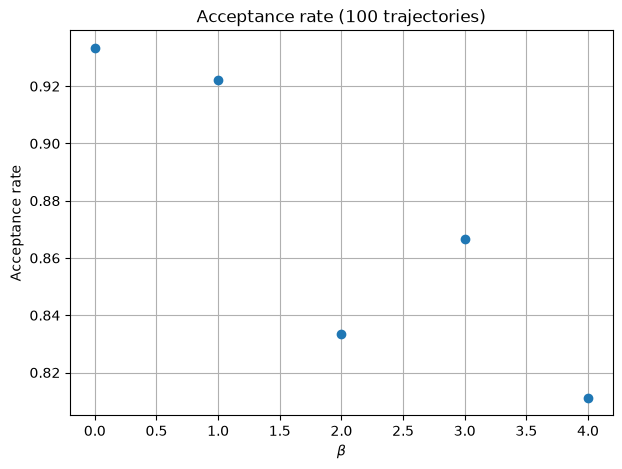

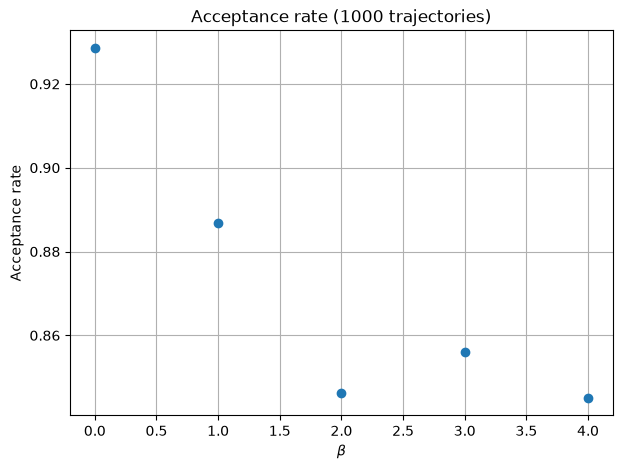

In [32]:
plot_acceptance(acc_100, trajectories=100)
plot_acceptance(acc_1000, trajectories=1000)

In [8]:
def parse_dH(logfile):

    data = []

    current_traj = None

    with open(logfile) as f:
        for line in f:

            m_traj = re.search(
                r"Plaquette:\s+\[\s*(\d+)\s*\]",
                line
            )

            if m_traj:
                current_traj = int(m_traj.group(1))


            m_dh = re.search(
                r"Total H after trajectory\s*=\s*([\d\.Ee+-]+)\s+dH\s*=\s*([\d\.Ee+-]+)",
                line
            )

            if m_dh and current_traj is not None:

                data.append({
                    "trajectory": current_traj,
                    "H_after": float(m_dh.group(1)),
                    "dH": float(m_dh.group(2))
                })

    return pd.DataFrame(data)

In [9]:
dh_measurements = []

for log in logs:

    dh = parse_dH(log)

    params = parse_log_name(log)

    for key,value in params.items():
        dh[key] = value

    dh["file"] = log.name

    dh_measurements.append(dh)


df_dh = pd.concat(dh_measurements)

df_dh = df_dh.drop_duplicates(
    subset=["file","trajectory"]
)


In [35]:
df_dh["exp_minus_dH"] = np.exp(-df_dh["dH"])

df_beta_scan_dh = df_dh[(df_dh.mdsteps == 10) & (df_dh.trajL == 1.0) & (df_dh.beta != 5.6)]
df_mdsteps_scan_dh = df_dh[(df_dh.beta == 2) & (df_dh.trajL == 1.0) & (df_dh.mdsteps != 40)]
df_trajL_scan_dh = df_dh[(df_dh.beta == 2) & (df_dh.mdsteps == 10)]

df_dh_traj100 = df_beta_scan_dh[(df_beta_scan_dh.trajectories==100)&(df_beta_scan_dh.trajectory >19)]
df_dh_traj1000 = df_beta_scan_dh[(df_beta_scan_dh.trajectories==1000)&(df_beta_scan_dh.trajectory >99)]

df_dh_mdsteps_traj100 = df_mdsteps_scan_dh[(df_mdsteps_scan_dh.trajectories==100)&(df_mdsteps_scan_dh.trajectory >19)]
df_dh_mdsteps_traj1000 = df_mdsteps_scan_dh[(df_mdsteps_scan_dh.trajectories==1000)&(df_mdsteps_scan_dh.trajectory >99)]

df_dh_trajL_traj100 = df_trajL_scan_dh[(df_trajL_scan_dh.trajectories==100)&(df_trajL_scan_dh.trajectory >19)]
df_dh_trajL_traj1000 = df_trajL_scan_dh[(df_trajL_scan_dh.trajectories==1000)&(df_trajL_scan_dh.trajectory >99)]


In [ ]:
df_mdsteps5_dh = df_dh[(df_dh.mdsteps == 5)] #Achtung: für reversibility angepasst
df_mdsteps10_dh = df_dh[(df_dh.mdsteps == 10)]
df_mdsteps15_dh = df_dh[(df_dh.mdsteps == 15)]
df_mdsteps20_dh = df_dh[(df_dh.mdsteps == 20)]

In [11]:
def dH_stats(df):
    stats =(
    df    
    .groupby("beta")
    .dH
    .agg(
        mean="mean",
        std="std",
        N="count"
        )       
    )

    stats["sem"] = (
    stats["std"] /
    np.sqrt(stats["N"])
    )

    return stats

In [37]:
df_mdsteps_traj100.head()

,trajectory,plaquette,lattice,beta,mdsteps,trajL,trajectories,checkpoint,file
6982,1,0.291420,8x8x8x8,2.0,8,1.0,100,5,L8x8x8x8_beta2_md8_trajL1.0_traj100_ckpt5.log
6983,2,0.387830,8x8x8x8,2.0,8,1.0,100,5,L8x8x8x8_beta2_md8_trajL1.0_traj100_ckpt5.log
6984,3,0.438404,8x8x8x8,2.0,8,1.0,100,5,L8x8x8x8_beta2_md8_trajL1.0_traj100_ckpt5.log
6985,4,0.464678,8x8x8x8,2.0,8,1.0,100,5,L8x8x8x8_beta2_md8_trajL1.0_traj100_ckpt5.log
6986,5,0.478239,8x8x8x8,2.0,8,1.0,100,5,L8x8x8x8_beta2_md8_trajL1.0_traj100_ckpt5.log


In [38]:
dh_stats_traj100 = measurement_stats(df_dh_traj100, "dH" , "beta")
dh_stats_traj1000 = measurement_stats(df_dh_traj1000, "dH" , "beta")

dh_stats_mdsteps_traj100 = measurement_stats(df_dh_mdsteps_traj100, "dH", "mdsteps")
dh_stats_mdsteps_traj1000 = measurement_stats(df_dh_mdsteps_traj1000, "dH", "mdsteps")

dh_stats_trajL_traj100 = measurement_stats(df_dh_trajL_traj100, "dH", "trajL")
dh_stats_trajL_traj1000 = measurement_stats(df_dh_trajL_traj1000, "dH", "trajL")

In [13]:
dh_stats_mdsteps5 = measurement_stats(df_mdsteps5_dh, "dH", "mdsteps")  # Achtung: für reversibility angepasst
dh_stats_mdsteps10 = measurement_stats(df_mdsteps10_dh, "dH", "mdsteps")
dh_stats_mdsteps15 = measurement_stats(df_mdsteps15_dh, "dH", "mdsteps")
dh_stats_mdsteps20 = measurement_stats(df_mdsteps20_dh, "dH", "mdsteps")

In [15]:
dh_mdsteps_revers = pd.concat([dh_stats_mdsteps5, dh_stats_mdsteps10, dh_stats_mdsteps15, dh_stats_mdsteps20], ignore_index=True)

In [17]:
dh_mdsteps_revers.to_csv("/home/max/PhD/programs/su2/pure_gauge/assets/data/dH_measurements_mdsteps_revers.csv", index=False)

In [39]:
#Plotfunktion dH vs trajectories für alle beta
def plot_dH_history(df_plot, title=None):
    
    plt.figure(figsize=(8,5))

    for beta in sorted(df_plot.beta.unique()):
        subset = (
            df_plot[df_plot.beta == beta]
            .sort_values("trajectory")
        )

        plt.plot(
            subset.trajectory,
            subset.dH,
            ".",
            alpha=0.5,
            label=fr"$\beta={beta}$"
        )

    plt.xlabel("trajectory")
    plt.ylabel("dH")
    plt.legend()
    plt.grid()
    plt.axhline(0)

    if title:
        plt.title(title)

    plt.show()

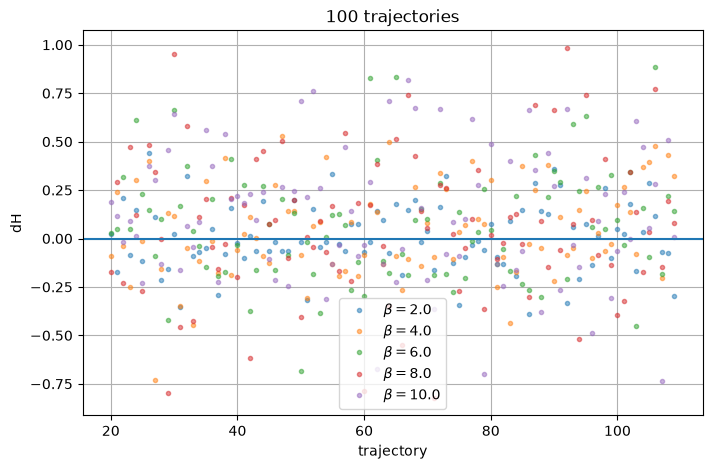

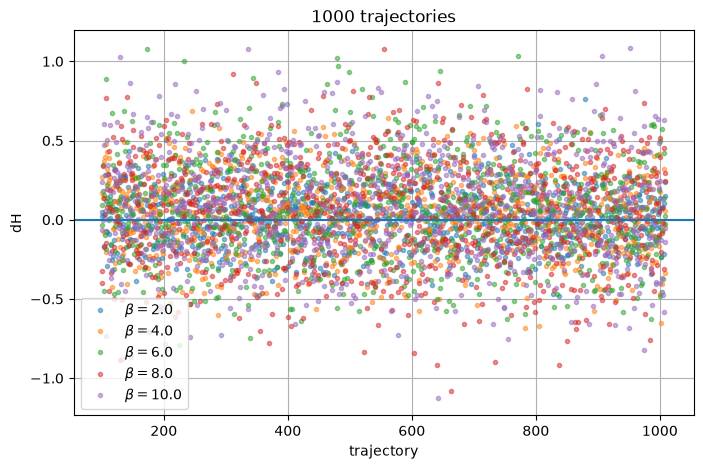

In [40]:
plot_dH_history(df_dh_traj100, title="100 trajectories")
plot_dH_history(df_dh_traj1000, title="1000 trajectories")

In [41]:
def plot_dH_histogram(df, beta=None, bins=40):

    plt.figure(figsize=(8,5))

    # Anzahl der Trajektorien aus DataFrame holen
    if "trajectories" in df.columns:
        traj_values = df.trajectories.unique()
        if len(traj_values) == 1:
            trajectories = traj_values[0]
        else:
            trajectories = None
    else:
        trajectories = None


    if beta is not None:

        df_plot = df[df.beta == beta]

        plt.hist(
            df_plot.dH,
            bins=bins,
            density=True,
            rwidth=0.9,
            alpha=0.7
        )

        title = (
            fr"$\Delta H$ distribution, "
            fr"$\beta={beta}$"
        )

    else:

        for b in sorted(df.beta.unique()):

            plt.hist(
                df[df.beta == b].dH,
                bins=bins,
                density=True,
                alpha=0.5,
                label=fr"$\beta={b}$"
            )

        plt.legend()

        title = r"$\Delta H$ distribution"


    if trajectories is not None:
        title += f" ({trajectories} trajectories)"


    plt.axvline(
        0,
        linestyle="--"
    )

    plt.xlabel(r"$\Delta H$")
    plt.ylabel("Probability density")

    plt.title(title)

    plt.grid()

    plt.show()

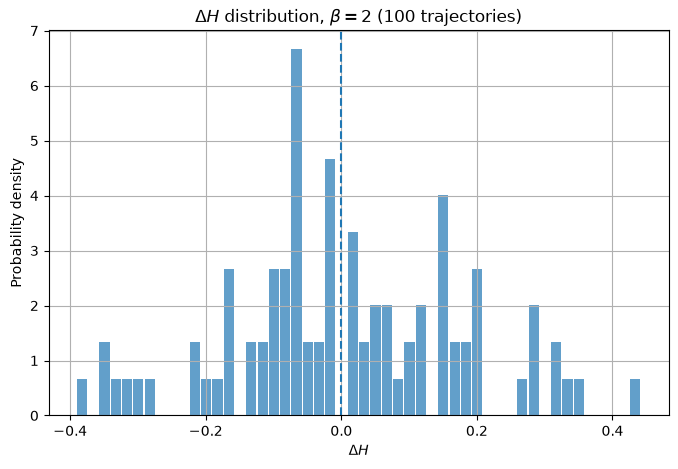

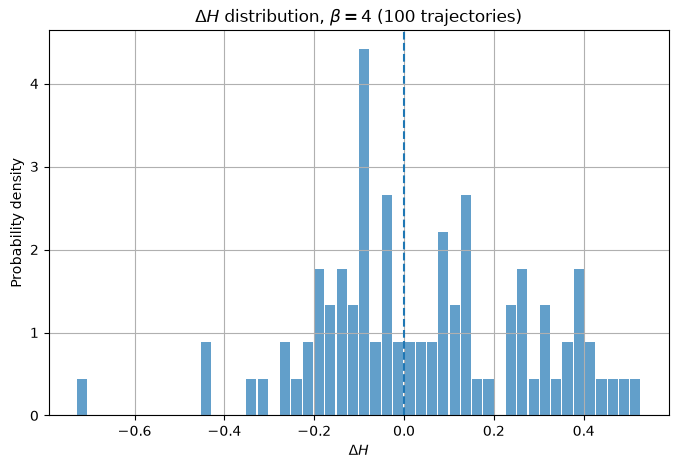

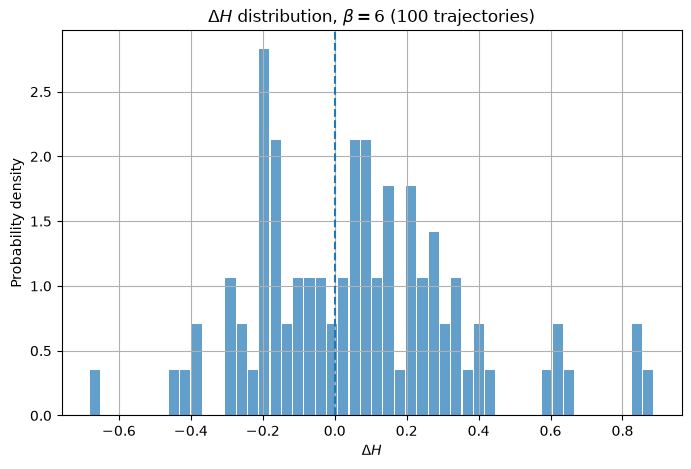

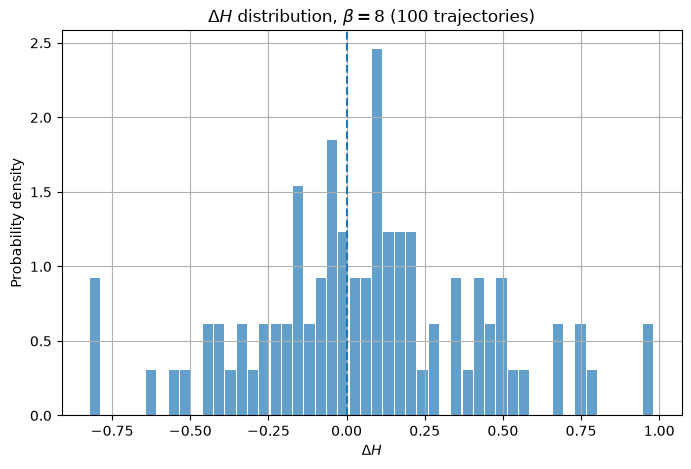

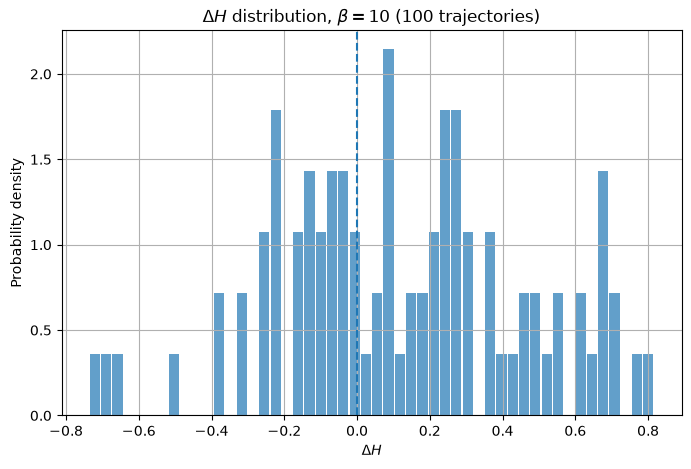

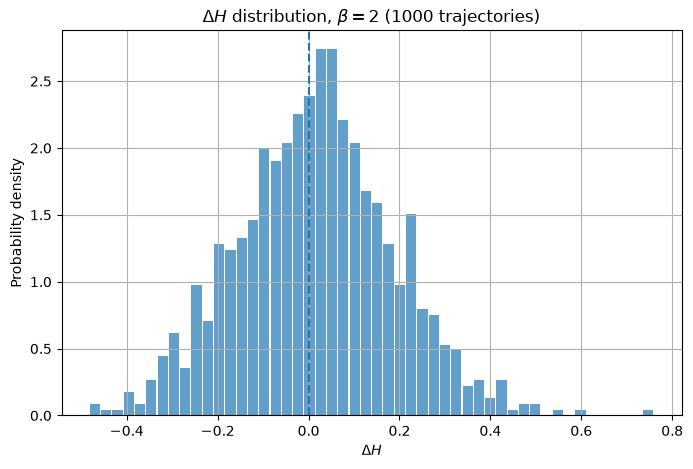

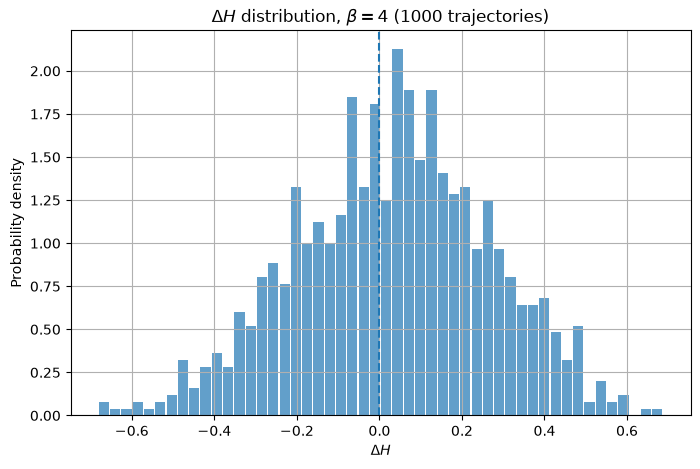

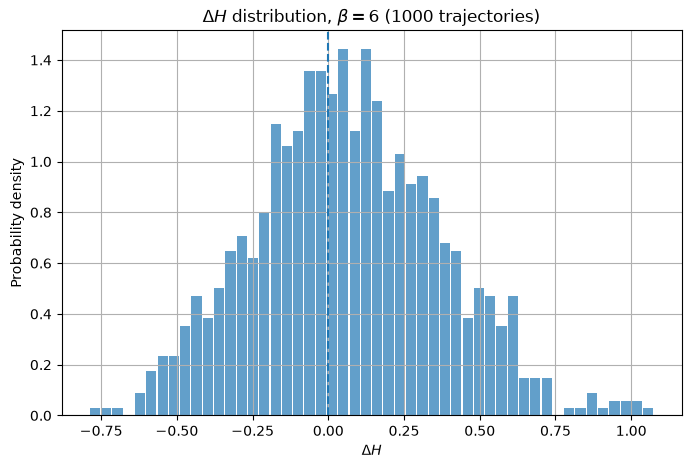

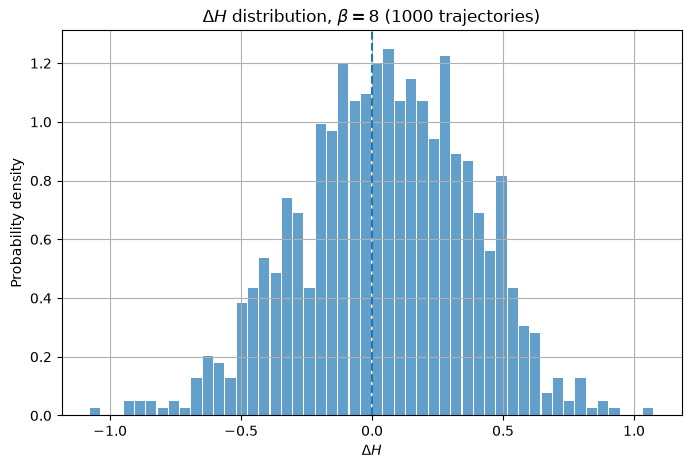

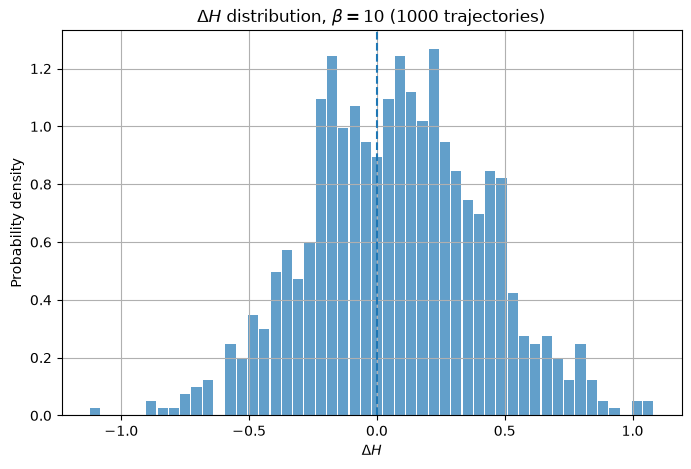

In [42]:
plot_dH_histogram(df_dh_traj100, beta=2, bins=50)
plot_dH_histogram(df_dh_traj100,beta=4, bins=50)
plot_dH_histogram(df_dh_traj100,beta=6, bins=50)
plot_dH_histogram(df_dh_traj100,beta=8, bins=50)
plot_dH_histogram(df_dh_traj100,beta=10, bins=50)

plot_dH_histogram(df_dh_traj1000, beta=2, bins=50)
plot_dH_histogram(df_dh_traj1000,beta=4, bins=50)
plot_dH_histogram(df_dh_traj1000,beta=6, bins=50)
plot_dH_histogram(df_dh_traj1000,beta=8, bins=50)
plot_dH_histogram(df_dh_traj1000,beta=10, bins=50)

In [43]:
analysis_100 = dh_stats_traj100.join(acc_100["acceptance"])
analysis_1000 = dh_stats_traj1000.join(acc_1000["acceptance"])

print(analysis_100.to_latex(index=False))
print(analysis_1000.to_latex(index=False))

\begin{tabular}{rrrrrr}
\toprule
beta & N & mean & std & sem & acceptance \\
\midrule
2.000000 & 90 & 0.004896 & 0.173860 & 0.018326 & 0.933333 \\
4.000000 & 90 & 0.041472 & 0.239281 & 0.025222 & 0.922222 \\
6.000000 & 90 & 0.066445 & 0.292599 & 0.030843 & 0.833333 \\
8.000000 & 90 & 0.062335 & 0.370234 & 0.039026 & 0.866667 \\
10.000000 & 90 & 0.122251 & 0.342594 & 0.036113 & 0.811111 \\
\bottomrule
\end{tabular}

\begin{tabular}{rrrrrr}
\toprule
beta & N & mean & std & sem & acceptance \\
\midrule
2.000000 & 910 & 0.016025 & 0.172717 & 0.005726 & 0.928571 \\
4.000000 & 910 & 0.032799 & 0.235376 & 0.007803 & 0.886813 \\
6.000000 & 910 & 0.063419 & 0.308012 & 0.010210 & 0.846154 \\
8.000000 & 910 & 0.049749 & 0.326870 & 0.010836 & 0.856044 \\
10.000000 & 910 & 0.077103 & 0.338868 & 0.011233 & 0.845055 \\
\bottomrule
\end{tabular}



In [44]:
def plot_acceptance_vs_dH(df, trajectories=None):

    plt.figure(figsize=(8,5))

    plt.errorbar(
        df["mean"],
        df["acceptance"],
        xerr=df["sem"],
        fmt="o",
        capsize=4
    )

    offsets = [
        (10, 10), 
        (10, 10),
        (10, 10),
        (10, 10),
        (10, 10)
    ]

    for i, beta in enumerate(df["beta"]):

        plt.annotate(
            fr"$\beta={beta}$",
            (
                df.loc[i, "mean"],
                df.loc[i, "acceptance"]
            ),
            xytext=offsets[i % len(offsets)],
            textcoords="offset points"
        )

    plt.xlabel(r"$\langle \Delta H\rangle$")
    plt.ylabel("Acceptance rate")

    if trajectories:
        plt.title(
            r"Acceptance rate vs $\langle \Delta H\rangle$ "
            f"({trajectories} trajectories)"
        )
    else:
        plt.title(
            r"Acceptance rate vs $\langle \Delta H\rangle$"
        )

    plt.margins(x=0.15, y=0.15)

    plt.grid()
    plt.show()

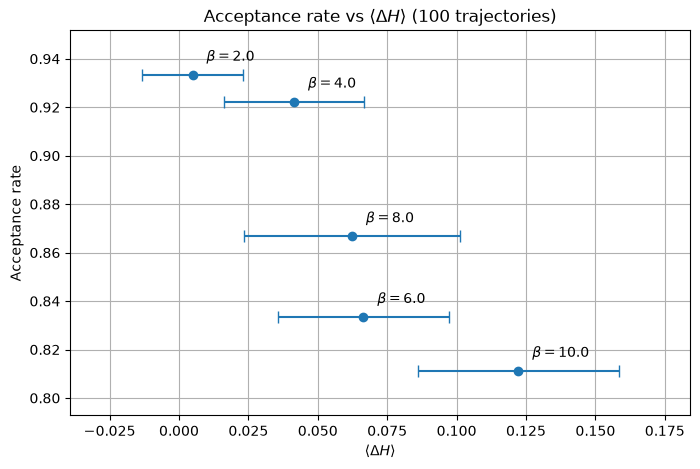

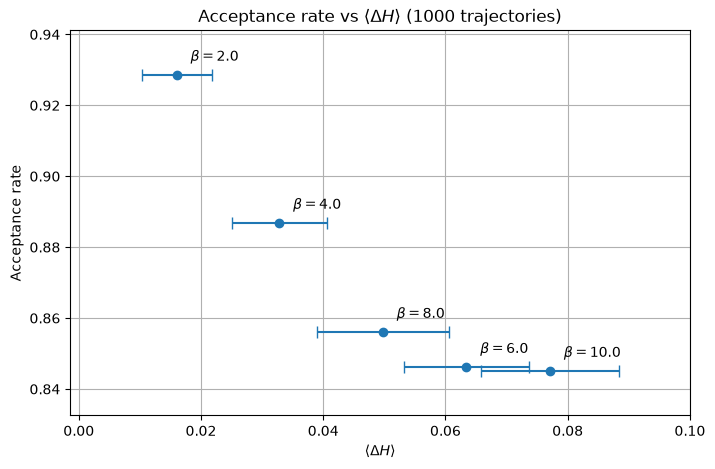

In [45]:
plot_acceptance_vs_dH(analysis_100, trajectories=100)
plot_acceptance_vs_dH(analysis_1000, trajectories=1000)

In [46]:
def exp_dH_stats(df):

    stats = (
        df
        .groupby("beta")
        .exp_minus_dH
        .agg(
            mean="mean",
            std="std",
            N="count"
        )
    )

    stats["sem"] = stats["std"] / np.sqrt(stats["N"])

    return stats

In [47]:
exp_dH_100 = measurement_stats(df_dh_traj100, "exp_minus_dH", "beta")
exp_dH_1000 = measurement_stats(df_dh_traj1000, "exp_minus_dH", "beta")

exp_dH_mdsteps_100 = measurement_stats(df_dh_mdsteps_traj100, "exp_minus_dH", "mdsteps")
exp_dH_mdsteps_1000 = measurement_stats(df_dh_mdsteps_traj1000, "exp_minus_dH", "mdsteps")

exp_dH_trajL_100 = measurement_stats(df_dh_trajL_traj100, "exp_minus_dH", "trajL")
exp_dH_trajL_1000 = measurement_stats(df_dh_trajL_traj1000, "exp_minus_dH", "trajL")

In [48]:
def plot_exp_dH(df_stats, trajectories=None):

    plt.figure(figsize=(8,5))

    plt.errorbar(
        df_stats["beta"],
        df_stats["mean"],
        yerr=df_stats["sem"],
        fmt="o",
        capsize=4
    )

    plt.axhline(
        1,
        linestyle="--",
        label=r"$\langle e^{-\Delta H}\rangle=1$"
    )

    plt.xlabel(r"$\beta$")
    plt.ylabel(r"$\langle e^{-\Delta H}\rangle$")

    if trajectories:
        plt.title(
            r"$\langle e^{-\Delta H}\rangle$ "
            f"({trajectories} trajectories)"
        )

    plt.grid()
    plt.legend()

    plt.show()

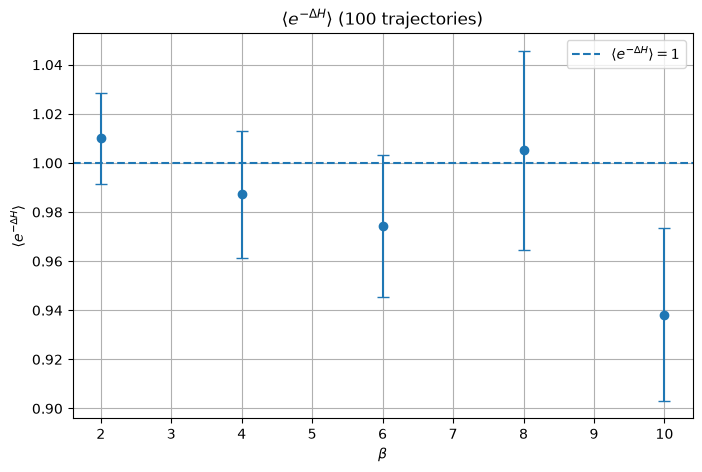

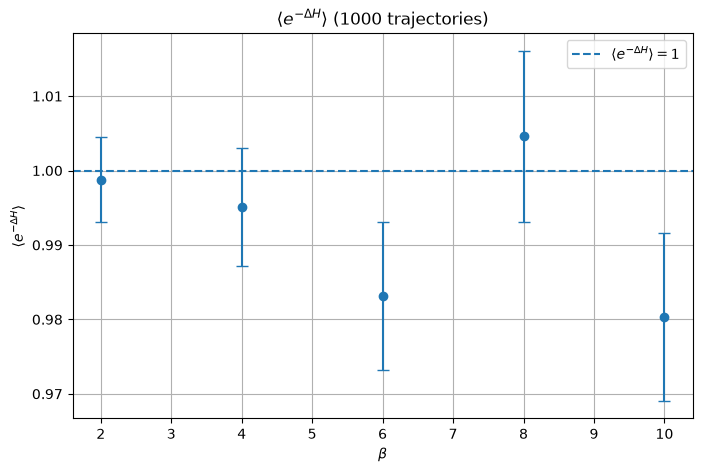

In [49]:
plot_exp_dH(exp_dH_100, trajectories=100)
plot_exp_dH(exp_dH_1000, trajectories=1000)

In [19]:
def plot_average_with_error(
    df,
    x,
    x_label,
    y_label,
    title=None
):

    plt.figure(figsize=(7,5))

    plt.errorbar(
        df[x],
        df["mean"],
        yerr=df["sem"],
        fmt="o",
        capsize=4
    )

    plt.xlabel(x_label)
    plt.ylabel(y_label)

    if title:
        plt.title(title)

    plt.grid()
    plt.show()

In [51]:
df_plaq_mdsteps_traj100["dtau"] = 1 / df_plaq_mdsteps_traj100["mdsteps"]
df_plaq_mdsteps_traj1000["dtau"] = 1 / df_plaq_mdsteps_traj1000["mdsteps"]

df_plaq_trajL_traj100["dtau"] = df_plaq_trajL_traj100["trajL"] /10
df_plaq_trajL_traj1000["dtau"] = df_plaq_trajL_traj1000["trajL"] /10

In [52]:
df_plaq_trajL_traj1000

,trajL,N,mean,std,sem,dtau
0,0.50,910,0.501701,0.003672,0.000122,0.050
1,1.00,910,0.501585,0.003472,0.000115,0.100
2,1.25,910,0.501189,0.003659,0.000121,0.125
3,2.00,910,0.501458,0.003568,0.000118,0.200


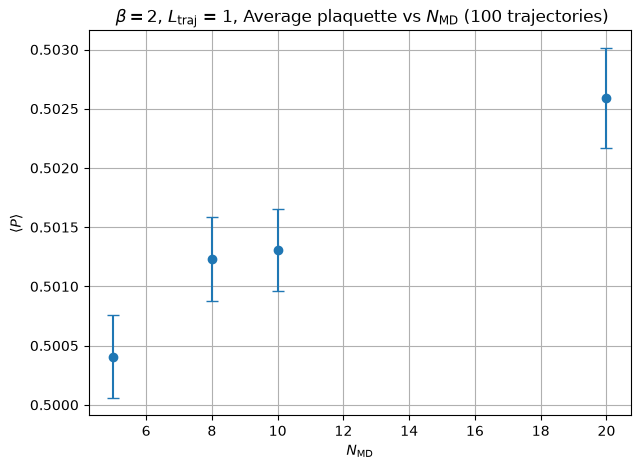

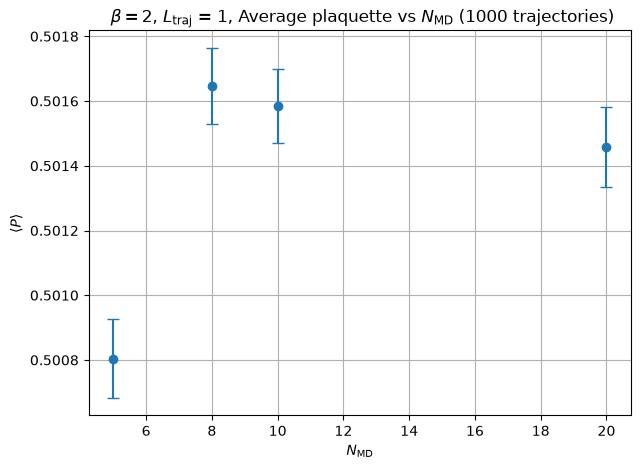

In [53]:
plot_average_with_error(
    df_plaq_mdsteps_traj100,
    x="mdsteps",
    x_label=r"$N_{\mathrm{MD}}$",
    y_label=r"$\langle P\rangle$",
    title=r" $\beta = 2$, $L_{\mathrm{traj}}$ = 1, Average plaquette vs $N_{\mathrm{MD}}$ (100 trajectories)"
)

plot_average_with_error(
    df_plaq_mdsteps_traj1000,
    x="mdsteps",
    x_label=r"$N_{\mathrm{MD}}$",
    y_label=r"$\langle P\rangle$",
    title=r" $\beta = 2$, $L_{\mathrm{traj}}$ = 1, Average plaquette vs $N_{\mathrm{MD}}$ (1000 trajectories)"
)

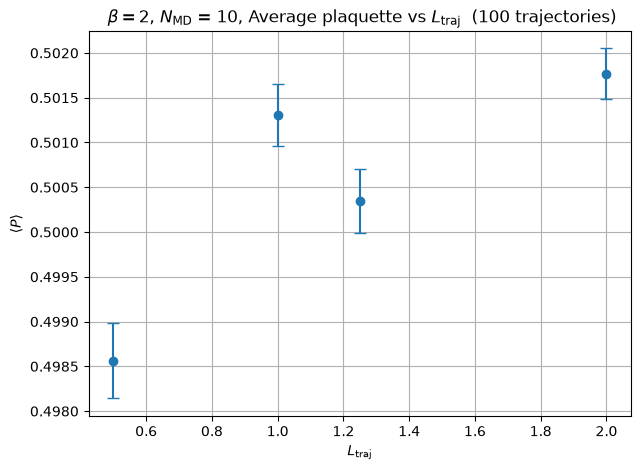

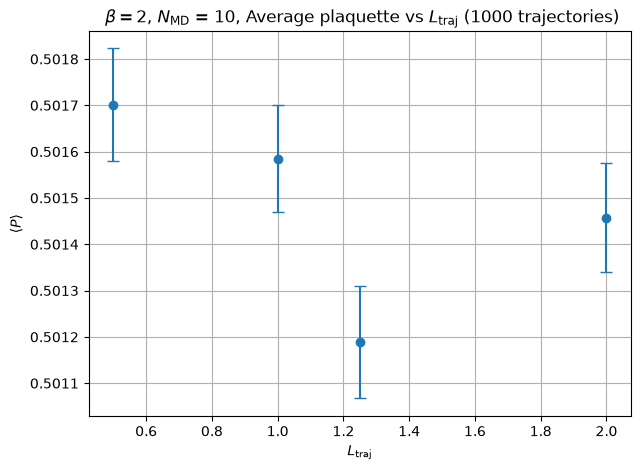

In [54]:
plot_average_with_error(
    df_plaq_trajL_traj100,
    x="trajL",
    x_label=r"$L_{\mathrm{traj}}$",
    y_label=r"$\langle P\rangle$",
    title=r" $\beta = 2$, $N_{\mathrm{MD}}$ = 10, Average plaquette vs $L_{\mathrm{traj}}$  (100 trajectories)"
)

plot_average_with_error(
    df_plaq_trajL_traj1000,
    x="trajL",
    x_label=r"$L_{\mathrm{traj}}$",
    y_label=r"$\langle P\rangle$",
    title=r" $\beta = 2$, $N_{\mathrm{MD}}$ = 10, Average plaquette vs $L_{\mathrm{traj}}$ (1000 trajectories)"
)

In [55]:
dh_stats_mdsteps_traj100["dtau"] = 1 / dh_stats_mdsteps_traj100["mdsteps"]
dh_stats_mdsteps_traj1000["dtau"] = 1 / dh_stats_mdsteps_traj1000["mdsteps"]

dh_stats_trajL_traj100["dtau"] = dh_stats_trajL_traj100["trajL"] /10
dh_stats_trajL_traj1000["dtau"] = dh_stats_trajL_traj1000["trajL"] /10

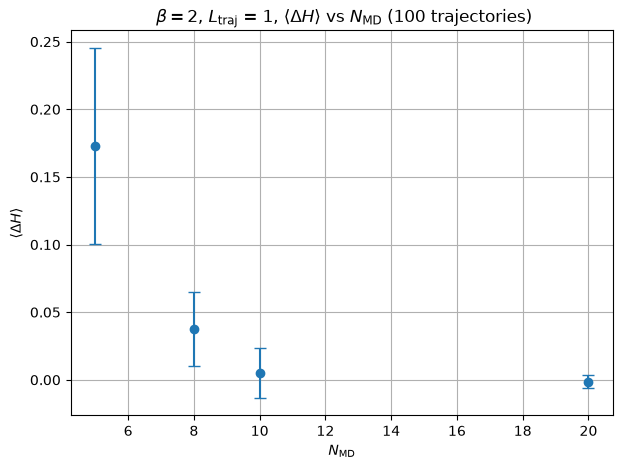

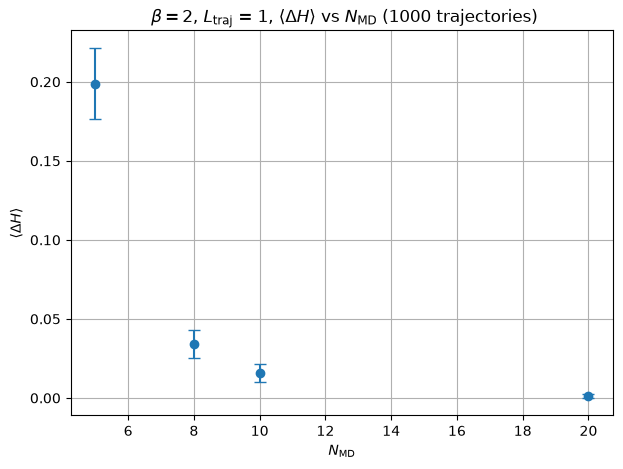

In [56]:
plot_average_with_error(
    dh_stats_mdsteps_traj100,
    x="mdsteps",
    x_label=r"$N_{\mathrm{MD}}$",
    y_label=r"$\langle \Delta H \rangle$",
    title=r" $\beta = 2$, $L_{\mathrm{traj}}$ = 1, $\langle \Delta H \rangle$ vs $N_{\mathrm{MD}}$ (100 trajectories)"
)

plot_average_with_error(
    dh_stats_mdsteps_traj1000,
    x="mdsteps",
    x_label=r"$N_{\mathrm{MD}}$",
    y_label=r"$\langle \Delta H \rangle$",
    title=r" $\beta = 2$, $L_{\mathrm{traj}}$ = 1, $\langle \Delta H \rangle$ vs $N_{\mathrm{MD}}$ (1000 trajectories)"
)

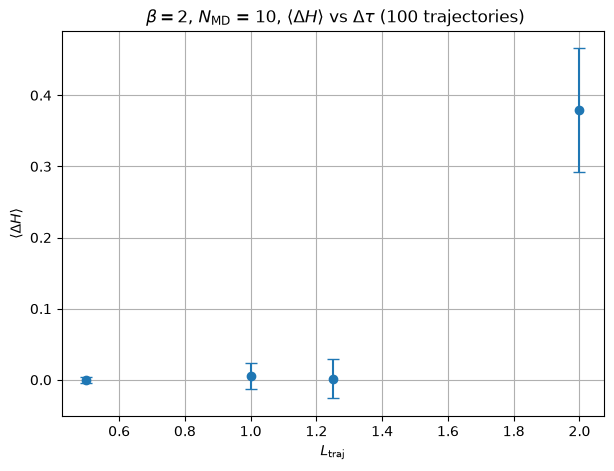

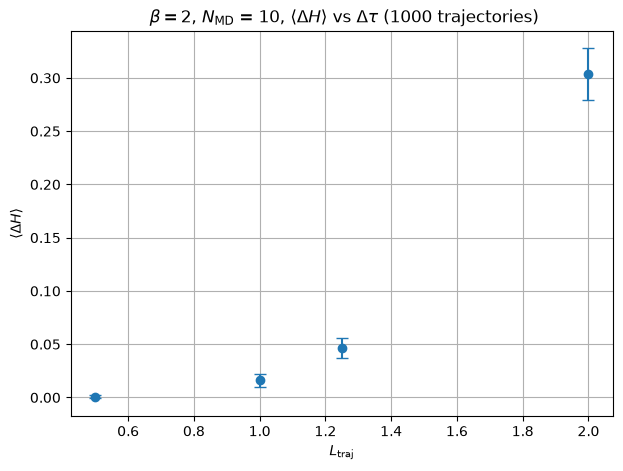

In [57]:
plot_average_with_error(
    dh_stats_trajL_traj100,
    x="trajL",
    x_label=r"$L_{\mathrm{traj}}$",
    y_label=r"$\langle \Delta H \rangle$",
    title=r" $\beta = 2$, $N_{\mathrm{MD}}$ = 10, $\langle \Delta H \rangle$ vs $\Delta \tau$ (100 trajectories)"
)

plot_average_with_error(
    dh_stats_trajL_traj1000,
    x="trajL",
    x_label=r"$L_{\mathrm{traj}}$",
    y_label=r"$\langle \Delta H \rangle$",
    title=r" $\beta = 2$, $N_{\mathrm{MD}}$ = 10, $\langle \Delta H \rangle$ vs $\Delta \tau$ (1000 trajectories)"
)

In [58]:
exp_dH_mdsteps_100["dtau"] = 1 / exp_dH_mdsteps_100["mdsteps"]
exp_dH_mdsteps_1000["dtau"] = 1 / exp_dH_mdsteps_1000["mdsteps"]

exp_dH_trajL_100["dtau"] = exp_dH_trajL_100["trajL"] /10
exp_dH_trajL_1000["dtau"] = exp_dH_trajL_1000["trajL"] /10

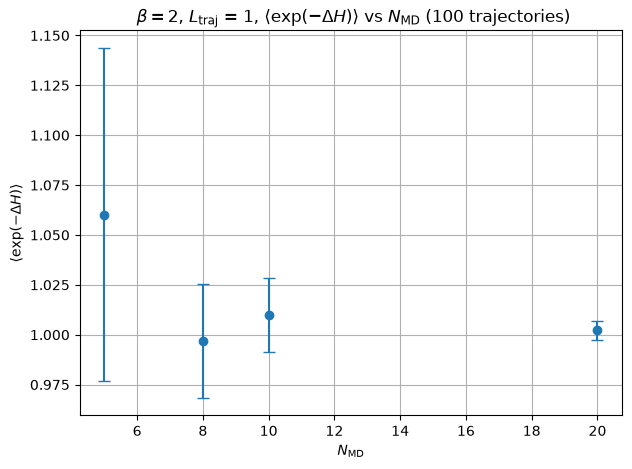

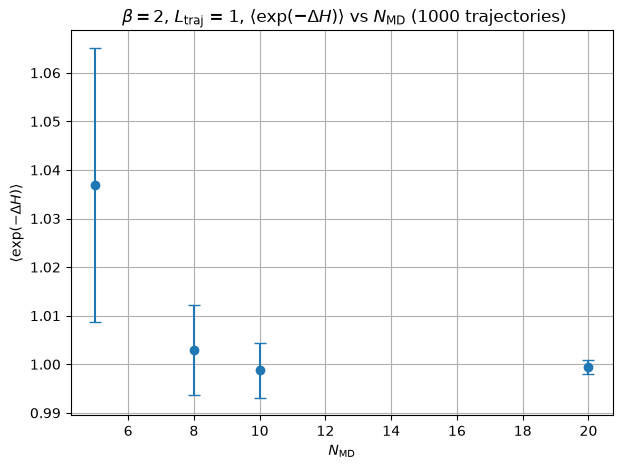

In [59]:
plot_average_with_error(
    exp_dH_mdsteps_100,
    x="mdsteps",
    x_label=r"$N_{\mathrm{MD}}$",
    y_label=r"$\langle \exp(-\Delta H) \rangle$",
    title=r" $\beta = 2$, $L_{\mathrm{traj}}$ = 1, $\langle \exp(-\Delta H) \rangle$ vs $N_{\mathrm{MD}}$ (100 trajectories)"
)

plot_average_with_error(
    exp_dH_mdsteps_1000,
    x="mdsteps",
    x_label=r"$N_{\mathrm{MD}}$",
    y_label=r"$\langle \exp(-\Delta H) \rangle$",
    title=r" $\beta = 2$, $L_{\mathrm{traj}}$ = 1, $\langle \exp(-\Delta H) \rangle$ vs $N_{\mathrm{MD}}$ (1000 trajectories)"
)

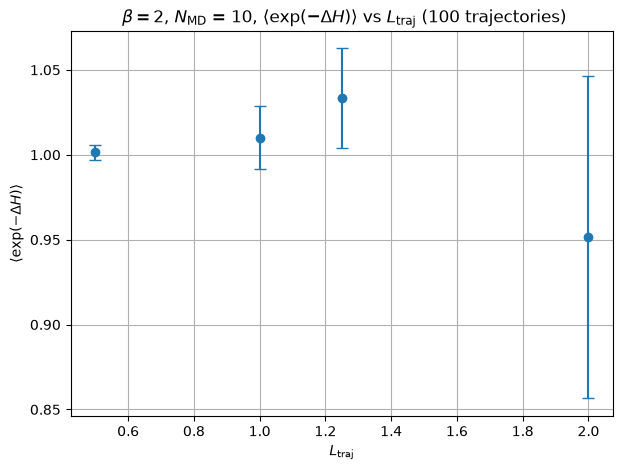

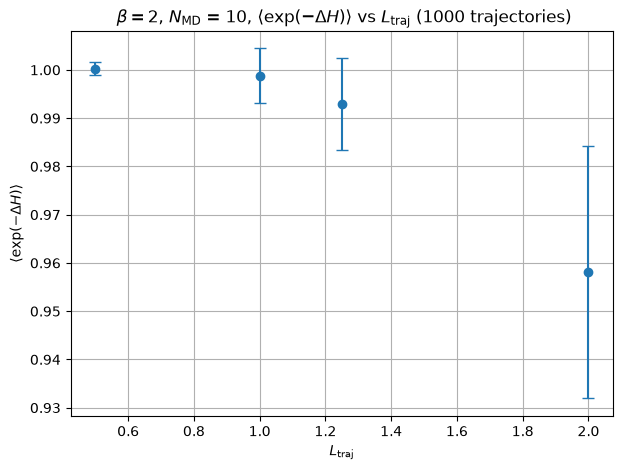

In [61]:
plot_average_with_error(
    exp_dH_trajL_100,
    x="trajL",
    x_label=r"$L_{\mathrm{traj}}$",
    y_label=r"$\langle \exp(-\Delta H) \rangle$",
    title=r" $\beta = 2$, $N_{\mathrm{MD}}$ = 10, $\langle \exp(-\Delta H) \rangle$ vs $L_{\mathrm{traj}}$ (100 trajectories)"
)

plot_average_with_error(
    exp_dH_trajL_1000,
    x="trajL",
    x_label=r"$L_{\mathrm{traj}}$",
    y_label=r"$\langle \exp(-\Delta H) \rangle$",
    title=r" $\beta = 2$, $N_{\mathrm{MD}}$ = 10, $\langle \exp(-\Delta H) \rangle$ vs $L_{\mathrm{traj}}$ (1000 trajectories)"
)

In [113]:
def plot_integrator_comparison(
    df_mdsteps,
    df_trajL,
    observable,
    trajectories=None,
    reference=None
):
    """
    Vergleicht einen MD-Step-Scan mit einem TrajL-Scan
    als Funktion der Schrittweite Δτ.
    """

    plt.figure(figsize=(8,5))

    plt.errorbar(
        df_mdsteps["dtau"],
        df_mdsteps["mean"],
        yerr=df_mdsteps["sem"],
        fmt="o",
        capsize=4,
        label=r"varying $N_{\mathrm{MD}}$"
    )

    plt.errorbar(
        df_trajL["dtau"],
        df_trajL["mean"],
        yerr=df_trajL["sem"],
        fmt="s",
        capsize=4,
        label=r"varying $L_{\mathrm{traj}}$"
    )

    if reference is not None:
        plt.axhline(
            reference,
            color="black",
            linestyle=":"
        )

    plt.xlabel(r"$\Delta\tau=L_{\rm traj}/N_{\rm MD}$")
    plt.ylabel(observable)

    if trajectories is not None:
        plt.title(
            f"{observable} vs $\\Delta\\tau$ "
            f"({trajectories} trajectories)"
        )
    else:
        plt.title(
            f"{observable} vs $\\Delta\\tau$"
        )

    plt.grid()
    plt.legend()
    plt.show()

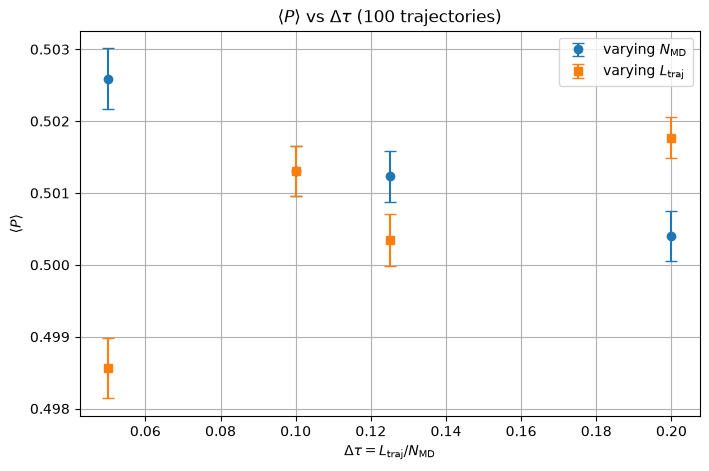

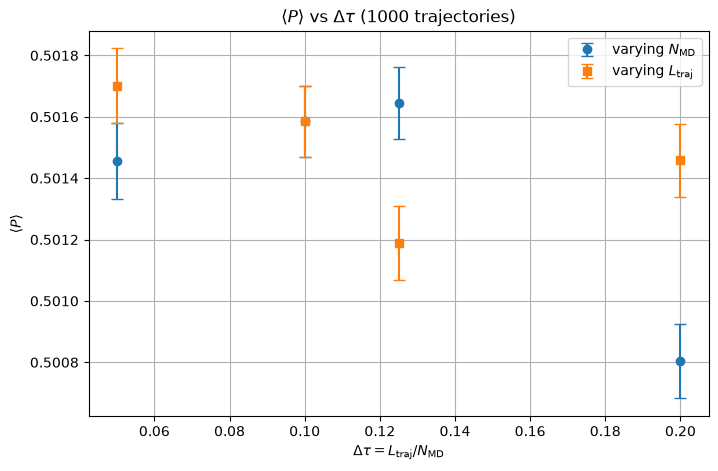

In [117]:
plot_integrator_comparison(
    df_plaq_mdsteps_traj100,
    df_plaq_trajL_traj100,
    observable=r"$\langle P\rangle$",
    trajectories=100
)

plot_integrator_comparison(
    df_plaq_mdsteps_traj1000,
    df_plaq_trajL_traj1000,
    observable=r"$\langle P\rangle$",
    trajectories=1000
)

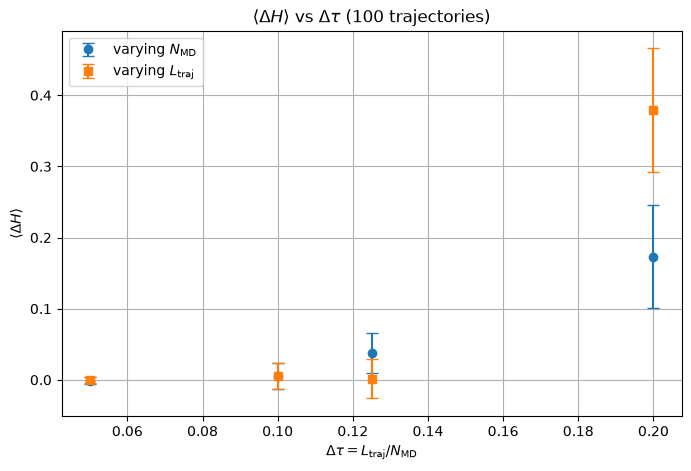

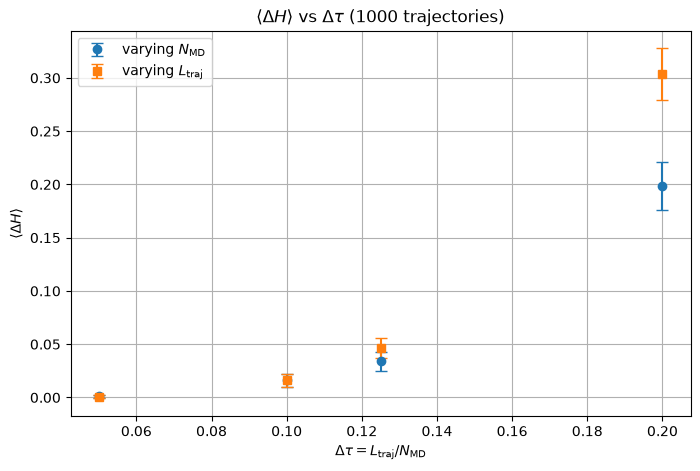

In [119]:
plot_integrator_comparison(
    dh_stats_mdsteps_traj100,
    dh_stats_trajL_traj100,
    observable=r"$\langle \Delta H\rangle$",
    trajectories=100
)

plot_integrator_comparison(
    dh_stats_mdsteps_traj1000,
    dh_stats_trajL_traj1000,
    observable=r"$\langle \Delta H\rangle$",
    trajectories=1000
)

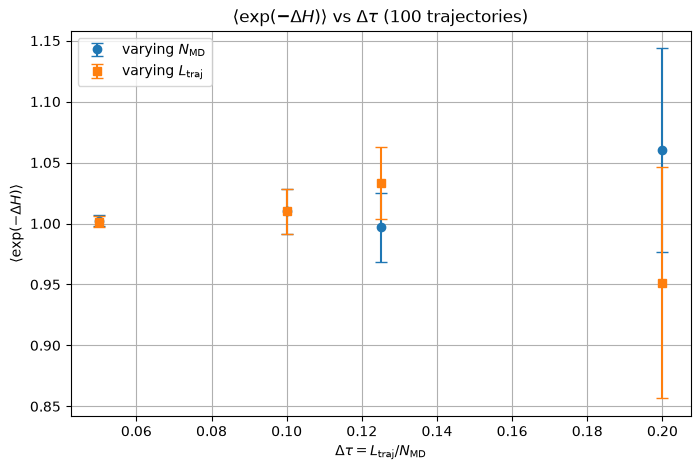

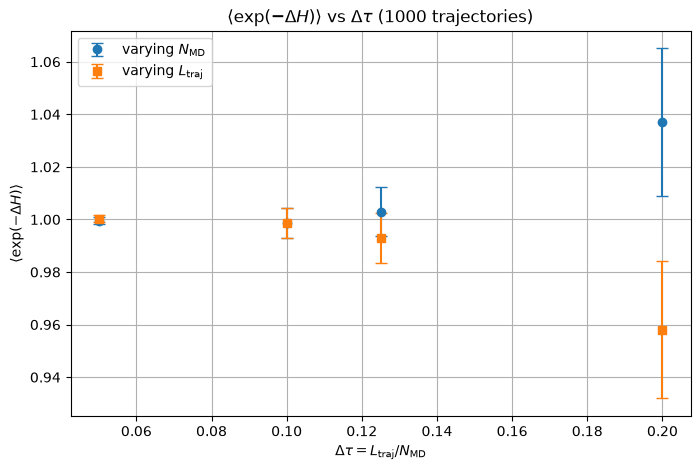

In [120]:
plot_integrator_comparison(
    exp_dH_mdsteps_100,
    exp_dH_trajL_100,
    observable=r"$\langle \exp(-\Delta H)\rangle$",
    trajectories=100
)

plot_integrator_comparison(
    exp_dH_mdsteps_1000,
    exp_dH_trajL_1000,
    observable=r"$\langle \exp(-\Delta H) \rangle$",
    trajectories=1000
)

In [ ]:
#statsmodels.tsa.stattools.acf(x, adjusted=False, nlags=None, qstat=False, fft=True, alpha=None, bartlett_confint=True, missing='none')
# x=verwendete werte
# adjusted = normiere mit n oder n-k, k ist die differnz zwischen den zeitpunkten t_1 und t_2
# nlags = abstand bis zu dem werte verglichen werden
# qstat = irgendwas mit statisitk
# fft =acf durch fast fourier trafo (fft)
# alpha = gibt konfidenzintervall zurück, verwendet bartlett
# bartlett = art die standardabweichung zu berechnen
#missing = gibt an wie NaN behandelt werden 


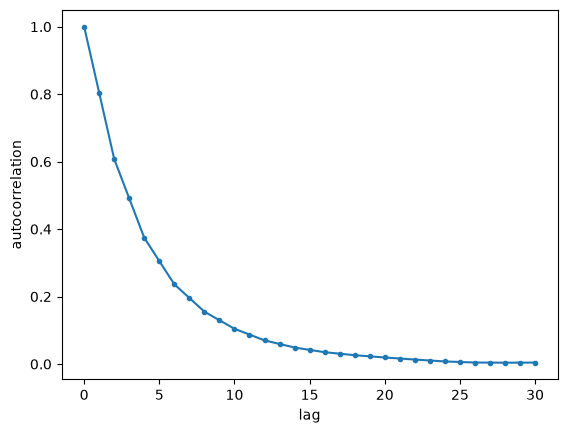

In [38]:
from statsmodels.tsa.stattools import acf

subset = df[
    (df.beta == 6) 
]

plaq = subset.plaquette.values

acf_values = acf(
    plaq,
    nlags=30
)

plt.plot(acf_values, marker=".")
plt.xlabel("lag")
plt.ylabel("autocorrelation")
plt.show()

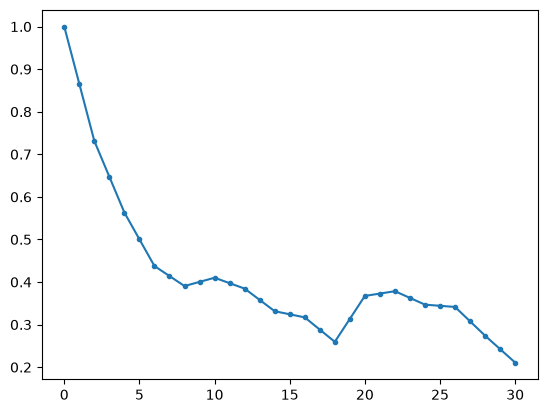

In [33]:
subset = df[
    (df.beta == 6) &
    (df.trajectory > 20)
]

subset = subset.sort_values("trajectory")

plaq = subset.plaquette.values

acf_values = acf(plaq, nlags=30)

plt.plot(acf_values, marker=".")
plt.show()

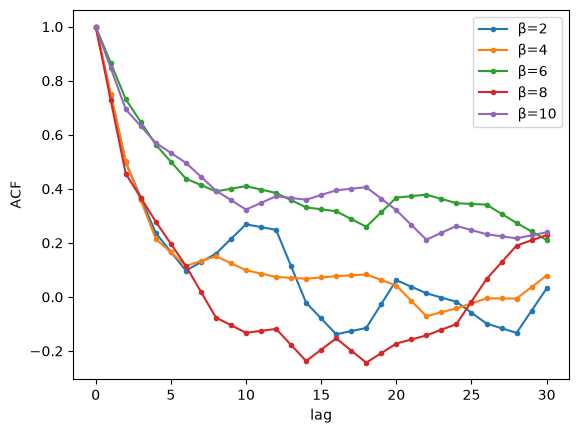

In [37]:
for beta in [2,4,6,8,10]:

    subset = df[
        (df.beta == beta) &
        (df.trajectory > 20)
    ].sort_values("trajectory")

    plaq = subset.plaquette.values

    acf_values = acf(plaq, nlags=30)

    plt.plot(acf_values, marker=".", label=f"β={beta}")

plt.legend()
plt.xlabel("lag")
plt.ylabel("ACF")
plt.show()

In [39]:
from statsmodels.tsa.stattools import acf

for beta in [2,4,6,8,10]:

    subset = df[
        (df.beta == beta) &
        (df.trajectory > 20)
    ].sort_values("trajectory")

    plaq = subset.plaquette.values

    acf_values = acf(plaq, nlags=20)

    tau_int = 0.5 + sum(acf_values[1:])

    print(beta, tau_int)

2 3.560556312867012
4 3.825653933957336
6 9.20148919974472
8 0.5156237485347983
10 9.501125137899672


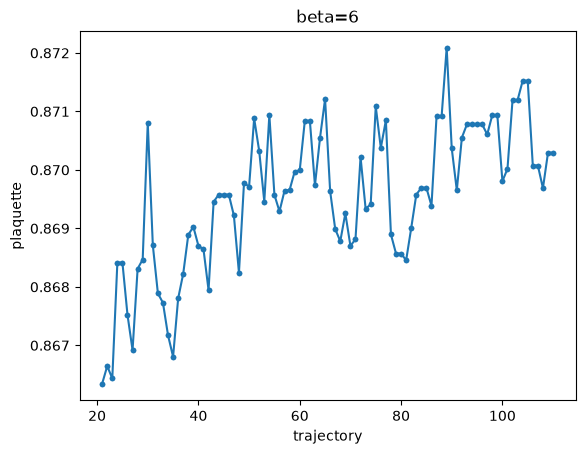

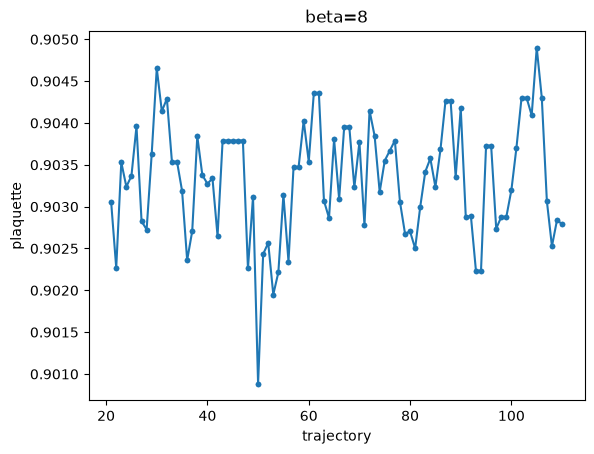

In [40]:
for beta in [6,8]:

    subset = df[
        (df.beta == beta) &
        (df.trajectory > 20)
    ].sort_values("trajectory")

    plt.plot(
        subset.trajectory,
        subset.plaquette,
        marker="."
    )

    plt.title(f"beta={beta}")
    plt.xlabel("trajectory")
    plt.ylabel("plaquette")
    plt.show()

In [121]:
def parse_topology(log):

    data = []

    with open(log) as f:
        for line in f:

            m = re.search(
                r"Topological Charge:\s*\[\s*(\d+)\s*\]\s*([-0-9.eE+]+)",
                line
            )

            if m:
                data.append({
                    "trajectory": int(m.group(1)),
                    "Q": float(m.group(2))
                })

    return pd.DataFrame(data)

In [124]:
q_measurements = []

for log in logs:

    q = parse_topology(log)

    params = parse_log_name(log)

    for key, value in params.items():
        q[key] = value

    q["file"] = log.name

    q_measurements.append(q)

df_q = pd.concat(q_measurements, ignore_index=True)

In [125]:
df_q_traj100 = df_q[
    (df_q.trajectories == 100) &
    (df_q.trajectory > 20)
]

df_q_traj1000 = df_q[
    (df_q.trajectories == 1000) &
    (df_q.trajectory > 100)
]

In [123]:
def plot_topology_history(df, beta=None, trajectories=None):

    plt.figure(figsize=(8,5))

    if beta is None:

        # Alle beta plotten
        for b in sorted(df.beta.unique()):

            subset = (
                df[df.beta == b]
                .sort_values("trajectory")
            )

            plt.plot(
                subset.trajectory,
                subset.Q,
                ".-",
                label=fr"$\beta={b}$"
            )

        title = "Topological charge"

        plt.legend()

    else:

        # Nur ein beta plotten
        subset = (
            df[df.beta == beta]
            .sort_values("trajectory")
        )

        plt.plot(
            subset.trajectory,
            subset.Q,
            ".-"
        )

        title = fr"Topological charge ($\beta={beta}$)"


    if trajectories is not None:
        title += f" ({trajectories} trajectories)"

    plt.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=1
    )

    plt.xlabel("Trajectory")
    plt.ylabel(r"$Q$")
    plt.title(title)

    plt.grid()

    plt.show()

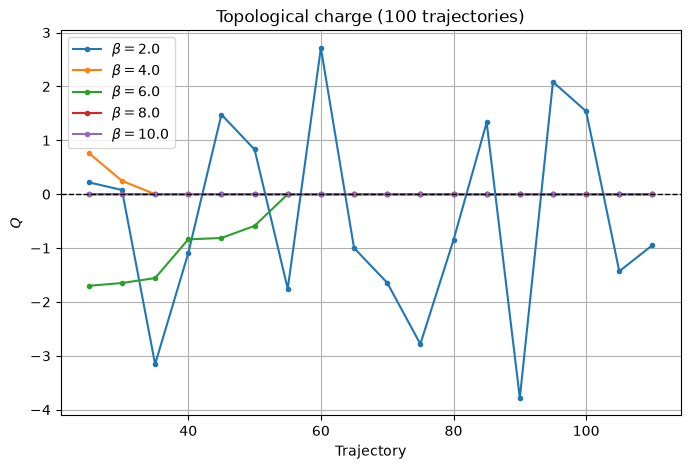

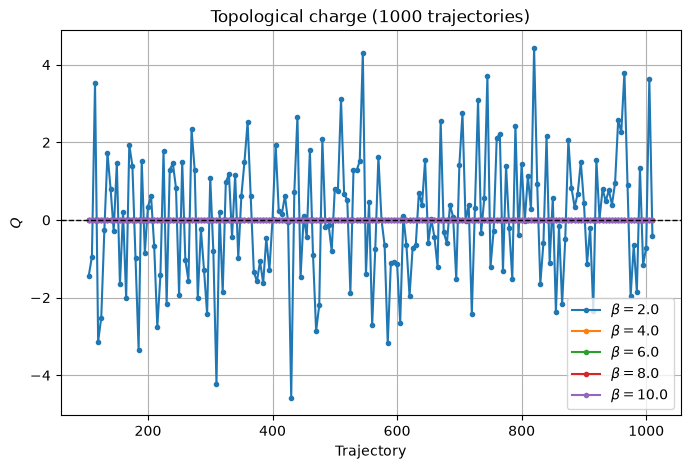

In [126]:
plot_topology_history(
    df_q_traj100,
    trajectories=100
)
plot_topology_history(
    df_q_traj1000,
    trajectories=1000
)

In [44]:
logfile = log_dir / "L8x8x8x8_beta6_md10_trajL1.0_traj100_ckpt5.log"

q = parse_topology(logfile)

q[:5]

[{'trajectory': 5, 'Q': -1.401114057529427},
 {'trajectory': 10, 'Q': -2.317731446012111},
 {'trajectory': 15, 'Q': -1.741037926784045},
 {'trajectory': 20, 'Q': -1.733078285691357},
 {'trajectory': 25, 'Q': -1.701356116330909}]

In [45]:
top_measurements = []

for log in logs:

    params = parse_log_name(log)

    qs = parse_topology(log)

    for q in qs:
        q.update(params)
        q["file"] = log.name
        top_measurements.append(q)


qdf = pd.DataFrame(top_measurements)

qdf.head()

,trajectory,Q,lattice,beta,mdsteps,trajL,trajectories,checkpoint,file
0,5,0.800794,8x8x8x8,4.0,10,1.0,100,5,L8x8x8x8_beta4_md10_trajL1.0_traj100_ckpt5.log
1,10,-0.148791,8x8x8x8,4.0,10,1.0,100,5,L8x8x8x8_beta4_md10_trajL1.0_traj100_ckpt5.log
2,15,0.848236,8x8x8x8,4.0,10,1.0,100,5,L8x8x8x8_beta4_md10_trajL1.0_traj100_ckpt5.log
3,20,0.824696,8x8x8x8,4.0,10,1.0,100,5,L8x8x8x8_beta4_md10_trajL1.0_traj100_ckpt5.log
4,25,0.763690,8x8x8x8,4.0,10,1.0,100,5,L8x8x8x8_beta4_md10_trajL1.0_traj100_ckpt5.log


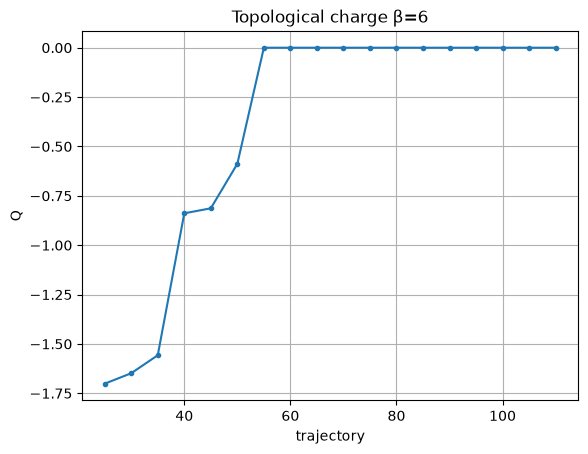

In [46]:
subset = qdf[
    (qdf.beta == 6) &
    (qdf.trajectory > 20)
].sort_values("trajectory")

plt.plot(
    subset.trajectory,
    subset.Q,
    ".-"
)

plt.xlabel("trajectory")
plt.ylabel("Q")
plt.title("Topological charge β=6")
plt.grid()
plt.show()

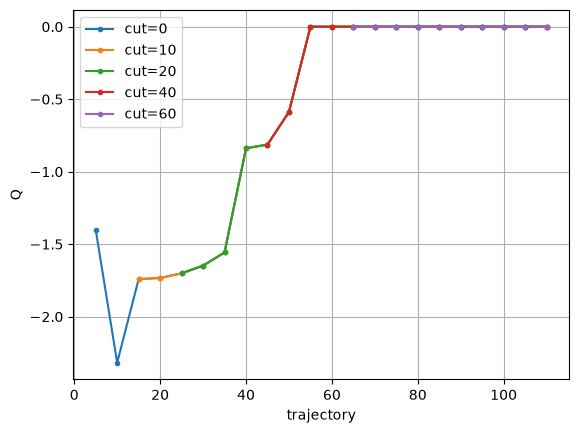

In [47]:
for cut in [0,10,20,40,60]:

    subset = qdf[
        (qdf.beta == 6) &
        (qdf.trajectory > cut)
    ].sort_values("trajectory")

    plt.plot(
        subset.trajectory,
        subset.Q,
        ".-",
        label=f"cut={cut}"
    )

plt.xlabel("trajectory")
plt.ylabel("Q")
plt.legend()
plt.grid()
plt.show()

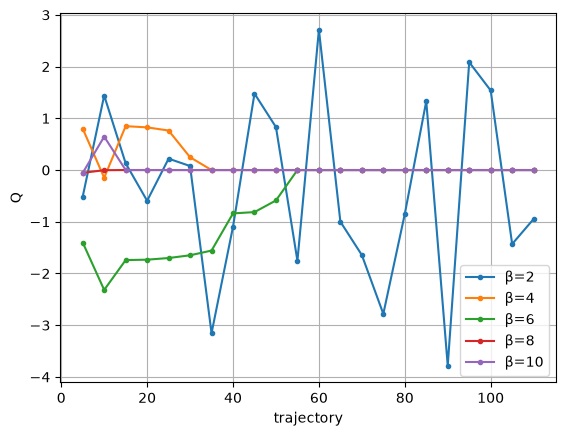

In [48]:
for beta in [2,4,6,8,10]:

    subset = qdf[
        (qdf.beta == beta)
    ].sort_values("trajectory")

    plt.plot(
        subset.trajectory,
        subset.Q,
        ".-",
        label=f"β={beta}"
    )

plt.xlabel("trajectory")
plt.ylabel("Q")
plt.legend()
plt.grid()
plt.show()

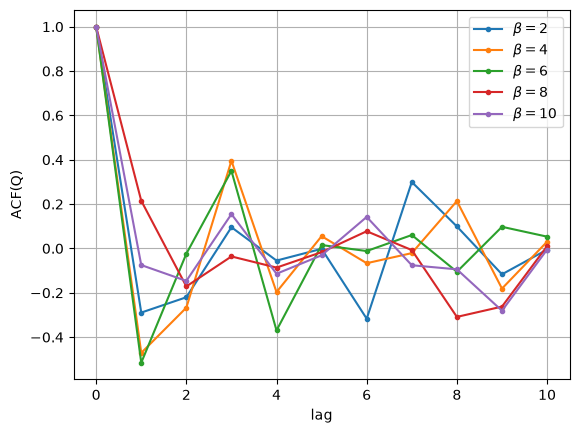

In [52]:
from statsmodels.tsa.stattools import acf

for beta in [2,4,6,8,10]:

    subset = qdf[
        (qdf.beta == beta) &
        (qdf.trajectory > 50)
    ].sort_values("trajectory")

    Q = subset.Q.values

    ac = acf(Q, nlags=10)

    plt.plot(ac, ".-", label=f"$\\beta={beta}$")

plt.xlabel("lag")
plt.ylabel("ACF(Q)")
plt.legend()
plt.grid()
plt.show()